In [1]:
# =============================================================================
# Block 1. 导入依赖与固定随机种子
# 作用：
# 1) 统一导入整个 notebook 需要用到的库；
# 2) 固定随机种子，减少实验结果漂移；
# 3) 关闭不必要的警告，提升 notebook 可读性。
# =============================================================================
from __future__ import annotations  

import gc  # garbage collection support
import io  # in-memory buffer helpers for profiling
import json  # JSON 编码和解码模块，用于处理 JSON 数据
import math  # 数学函数库，提供数学运算和常数
import os  # 操作系统接口模块，用于与操作系统进行交互，如文件和目录操作
import copy  # 深拷贝模块（统一在 Block 1 导入，后续不再重复）
import random
import re  # 正则表达式模块，用于字符串匹配和处理
import sys  # 系统特定参数和函数模块，用于与操作系统进行交互
import time  # 时间模块，用于处理时间相关的函数
import warnings
from collections import Counter, defaultdict  # 用于计数和创建默认字典
from dataclasses import asdict, dataclass, field  # 用于创建数据类，简化类的定义
from pathlib import Path  # 用于处理文件路径，提供面向对象的路径操作
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import joblib   # 用于并行计算和模型持久化
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy.signal import butter, medfilt, sosfiltfilt  # 用于信号处理的函数
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
mne.set_log_level("WARNING")

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

print("✅ Block 1 完成：依赖导入成功，随机种子已固定。")



✅ Block 1 完成：依赖导入成功，随机种子已固定。


In [ ]:
# =============================================================================
# Block 2. 全局配置
# 作用：
# 1) 用 dataclass 管理实验参数；
# 2) 统一 XGBoost 调参、验证、导出配置；
# 3) 默认面向 10 位病人（chb01-chb10）。
# =============================================================================
@dataclass
class FeatureConfig:
    epoch_len_s: int = 2
    bandpass_low_hz: float = 0.5
    bandpass_high_hz: float = 50.0
    bandpass_method: str = "butter_sos"   # "butter_sos" or "fir_zero"
    butter_order: int = 4
    band_edges_hz: Tuple[int, ...] = tuple(range(0, 42, 2))   # 0,2,4,...,40
    synchrony_pairs_names: Tuple[Tuple[str, str], ...] = (
        ("FP1-F3", "FP2-F4"),
        ("F7-T7", "F8-T8"),
        ("C3-P3", "C4-P4"),
    )
    history_epochs: int = 3
    scale_to_uV: bool = True
    channel_missing_policy: str = "strict"   # "strict" or "zero_fill"


@dataclass
class EvalConfig:
    patient_ids: Tuple[str, ...] = tuple(f"chb{i:02d}" for i in range(1, 11))
    threshold_grid: Tuple[float, ...] = tuple(np.round(np.linspace(0.10, 0.95, 50), 3))
    min_duration_epochs: int = 3
    min_acceptable_sensitivity: float = 0.70
    neg_to_pos_ratio: int = 10
    min_neg_samples: int = 3000
    default_threshold: float = 0.50
    fixed_threshold_mode: bool = True
    fixed_threshold_value: float = 0.50

    svm_c: float = 1.0
    svm_gamma: str = "scale"
    rf_n_estimators: int = 300
    rf_max_depth: Optional[int] = None
    rf_min_samples_leaf: int = 1
    rf_max_features: str = "sqrt"
    rf_n_jobs: int = -1

    # XGBoost params
    xgb_n_estimators: int = 100
    xgb_max_depth: int = 6
    xgb_learning_rate: float = 0.05
    xgb_subsample: float = 0.9
    xgb_colsample_bytree: float = 0.9
    xgb_reg_lambda: float = 1.0
    xgb_min_child_weight: float = 1.0
    xgb_gamma: float = 0.0
    xgb_tree_method: str = "hist"
    xgb_n_jobs: int = -1

    top_k_features: int = 50
    selector_n_estimators: int = 80
    selector_max_depth: int = 4
    random_state: int = GLOBAL_SEED


@dataclass
class ExportConfig:
    export_subdir: str = "exported_models"
    model_filename: str = "rf_lightweight_model.joblib"
    metadata_filename: str = "rf_lightweight_metadata.json"
    service_script_filename: str = "serve_model.py"
    client_script_filename: str = "example_client.py"


@dataclass
class ExperimentConfig:
    data_root: str = r"D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0"
    cache_subdir: str = "feature_cache_refactored"
    feature: FeatureConfig = field(default_factory=FeatureConfig)
    eval: EvalConfig = field(default_factory=EvalConfig)
    export: ExportConfig = field(default_factory=ExportConfig)

    @property
    def channels(self) -> List[str]:
        """Cached: avoids rebuilding the list on every access (optimization #10+#17)."""
        if not hasattr(self, "_channels_cached"):
            ref_ch_names = [
                "FP1-F7", "F7-T7", "T7-P7", "P7-O1",
                "FP1-F3", "F3-C3", "C3-P3", "P3-O1",
                "FP2-F4", "F4-C4", "C4-P4", "P4-O2",
                "FP2-F8", "F8-T8", "T8-P8", "P8-O2",
                "FZ-CZ", "CZ-PZ", "P7-T7", "T7-FT9",
                "FT9-FT10", "FT10-T8", "T8-P8",
            ]
            self._channels_cached = list(dict.fromkeys(ref_ch_names))
        return self._channels_cached

    @property
    def cache_dir(self) -> Path:
        return Path(self.data_root) / self.cache_subdir

    @property
    def export_dir(self) -> Path:
        return Path(self.data_root) / self.export.export_subdir


CFG = ExperimentConfig()

print("当前配置摘要：")
print(f"  data_root              = {CFG.data_root}")
print(f"  cache_dir              = {CFG.cache_dir}")
print(f"  patient_ids            = {CFG.eval.patient_ids}")
print(f"  channel_missing_policy = {CFG.feature.channel_missing_policy}")
print(f"  history_epochs         = {CFG.feature.history_epochs} (总上下文 = {(CFG.feature.history_epochs + 1) * CFG.feature.epoch_len_s} 秒)")
print(f"  base_channels          = {len(CFG.channels)}")
print(f"  spectral_bands         = {len(CFG.feature.band_edges_hz) - 1}")
print(f"  xgb_tree_method        = {CFG.eval.xgb_tree_method}")
print(f"  fixed_threshold_mode   = {CFG.eval.fixed_threshold_mode} (value={CFG.eval.fixed_threshold_value:.2f})")
print("✅ Block 2 完成：全局配置已创建。")




当前配置摘要：
  data_root              = D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0
  cache_dir              = D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\feature_cache_refactored
  patient_ids            = ('chb01', 'chb02', 'chb03', 'chb04', 'chb05', 'chb06', 'chb07', 'chb08', 'chb09', 'chb10')
  channel_missing_policy = strict
  history_epochs         = 3 (总上下文 = 8 秒)
  base_channels          = 22
  spectral_bands         = 20
  xgb_tree_method        = hist
  fixed_threshold_mode   = True (value=0.50)
✅ Block 2 完成：全局配置已创建。


In [3]:
# =============================================================================
# Block 3. 基础工具函数
# 作用：
# 1) 统一创建目录；
# 2) 生成配置哈希；
# 3) 保存/加载 JSON；
# 4) 给缓存和导出文件提供稳定命名；
# 5) 通过 CACHE_SCHEMA_VERSION 强制区分不同代码版本产生的缓存。
# =============================================================================
CACHE_SCHEMA_VERSION = "v2_summary_parser_fix"

def ensure_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path


def make_json_safe(obj: Any) -> Any:
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    if isinstance(obj, tuple):
        return [make_json_safe(x) for x in obj]
    if isinstance(obj, list):
        return [make_json_safe(x) for x in obj]
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    return obj


_CONFIG_HASH_CACHE: Dict[int, str] = {}

def config_to_hash(cfg: ExperimentConfig) -> str:
    """Cached: avoids re-serializing config on every call (optimization #8)."""
    obj_id = id(cfg)
    cached = _CONFIG_HASH_CACHE.get(obj_id)
    if cached is not None:
        return cached
    cfg_dict = make_json_safe(asdict(cfg))
    hash_payload = {
        "cache_schema_version": CACHE_SCHEMA_VERSION,
        "config": cfg_dict,
    }
    cfg_str = json.dumps(hash_payload, sort_keys=True, ensure_ascii=False)
    result = joblib.hash(cfg_str)
    _CONFIG_HASH_CACHE[obj_id] = result
    return result


def save_json(data: Dict[str, Any], path: Path) -> None:
    ensure_dir(path.parent)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(make_json_safe(data), f, ensure_ascii=False, indent=2)


def load_json(path: Path) -> Dict[str, Any]:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def get_patient_cache_path(cfg: ExperimentConfig, patient_id: str) -> Path:
    cfg_hash = config_to_hash(cfg)[:12]
    ensure_dir(cfg.cache_dir)
    return cfg.cache_dir / f"{patient_id}_features_{cfg_hash}.joblib"


def get_export_paths(cfg: ExperimentConfig) -> Dict[str, Path]:
    export_dir = ensure_dir(cfg.export_dir)
    return {
        "model": export_dir / cfg.export.model_filename,
        "metadata": export_dir / cfg.export.metadata_filename,
        "service_script": export_dir / cfg.export.service_script_filename,
        "client_script": export_dir / cfg.export.client_script_filename,
    }


print("当前缓存版本:", CACHE_SCHEMA_VERSION)
print("当前配置哈希:", config_to_hash(CFG))
print("✅ Block 3 完成：工具函数可用。")



当前缓存版本: v2_summary_parser_fix
当前配置哈希: 42bda03c8a1c833100a17747b4947648
✅ Block 3 完成：工具函数可用。


In [4]:
# =============================================================================
# Block 4. 数据读取与标签辅助函数
# 作用：
# 1) 解析 CHB-MIT 的 summary 标注；
# 2) 规范化 EDF 通道名；
# 3) 严格/鲁棒地对齐目标导联；
# 4) 基于半开区间生成 epoch 级标签。
# =============================================================================
def parse_summary_to_dict(summary_path: Path) -> Dict[str, List[Tuple[int, int]]]:
    """
    解析 CHB-MIT 的 patient summary，兼容以下常见变体：
    1) File Name: chb01_03.edf
    2) File Name: chb02_16+.edf
    3) Seizure Start Time: 2996 seconds
    4) Seizure 1 Start Time: 2996 seconds
    """
    seizure_dict: Dict[str, List[Tuple[int, int]]] = {}
    current_file: Optional[str] = None
    current_start: Optional[int] = None

    if not summary_path.exists():
        return seizure_dict

    file_pattern = re.compile(r"File Name:\s*([^\s]+\.edf)", flags=re.IGNORECASE)
    start_pattern = re.compile(
        r"Seizure(?:\s+\d+)?\s+Start Time:\s*(\d+)\s*(?:seconds?)?",
        flags=re.IGNORECASE,
    )
    end_pattern = re.compile(
        r"Seizure(?:\s+\d+)?\s+End Time:\s*(\d+)\s*(?:seconds?)?",
        flags=re.IGNORECASE,
    )

    with open(summary_path, "r", encoding="utf-8", errors="ignore") as f:
        for raw_line in f:
            line = raw_line.strip()

            file_match = file_pattern.search(line)
            if file_match:
                current_file = Path(file_match.group(1)).name
                seizure_dict.setdefault(current_file, [])
                current_start = None
                continue

            start_match = start_pattern.search(line)
            if start_match:
                current_start = int(start_match.group(1))
                continue

            end_match = end_pattern.search(line)
            if end_match and current_file is not None and current_start is not None:
                current_end = int(end_match.group(1))
                if current_end > current_start:
                    seizure_dict[current_file].append((current_start, current_end))
                current_start = None

    return seizure_dict

def normalize_channel_name(name: str) -> str:
    name = name.strip().upper()
    name = re.sub(r"-\d+$", "", name)
    name = re.sub(r"\s+", "", name)
    return name


def deduplicate_and_normalize_raw(raw: mne.io.BaseRaw) -> mne.io.BaseRaw:
    original_names = raw.ch_names
    normalized_names = [normalize_channel_name(ch) for ch in original_names]

    seen = set()
    to_drop = []
    rename_map = {}
    for old_name, new_name in zip(original_names, normalized_names):
        if new_name in seen:
            to_drop.append(old_name)
        else:
            seen.add(new_name)
            rename_map[old_name] = new_name

    if to_drop:
        raw.drop_channels(to_drop)
    raw.rename_channels(rename_map)
    return raw


def align_channels(
    raw: mne.io.BaseRaw,
    target_channels: Sequence[str],
    policy: str = "strict",
) -> Tuple[np.ndarray, Dict[str, Any]]:
    normalized_targets = [normalize_channel_name(ch) for ch in target_channels]

    # Fetch full EDF matrix once to avoid repeated disk IO per channel.
    raw_data = raw.get_data()
    existing_names = [normalize_channel_name(ch) for ch in raw.ch_names]
    name_to_idx = {name: idx for idx, name in enumerate(existing_names)}

    n_ch = len(normalized_targets)
    missing_channels = []
    reversed_channels = []
    n_times = raw_data.shape[1]

    # Pre-allocate output matrix instead of list + vstack
    data = np.zeros((n_ch, n_times), dtype=raw_data.dtype)

    for i, target in enumerate(normalized_targets):
        idx = name_to_idx.get(target)
        if idx is not None:
            data[i] = raw_data[idx]
            continue

        if "-" in target:
            reverse_target = "-".join(target.split("-")[::-1])
            reverse_idx = name_to_idx.get(reverse_target)
            if reverse_idx is not None:
                np.negative(raw_data[reverse_idx], out=data[i])
                reversed_channels.append(target)
                continue

        if policy == "zero_fill":
            # data[i] is already zeros
            missing_channels.append(target)
        else:
            raise ValueError(f"Missing target channel: {target}")

    info = {
        "missing_channels": missing_channels,
        "missing_count": len(missing_channels),
        "reversed_channels": reversed_channels,
    }
    return data, info
def build_epoch_labels(
    n_epochs: int,
    epoch_len_s: int,
    seizure_intervals: Sequence[Tuple[int, int]],
) -> np.ndarray:
    """Vectorized: broadcast over epochs instead of Python for-loop."""
    labels = np.zeros(n_epochs, dtype=np.int8)
    if not seizure_intervals:
        return labels
    epoch_starts = np.arange(n_epochs) * epoch_len_s
    epoch_ends = epoch_starts + epoch_len_s
    for sz_start, sz_end in seizure_intervals:
        overlap = (epoch_starts < sz_end) & (sz_start < epoch_ends)
        labels[overlap] = 1
    return labels


print("✅ Block 4 完成：数据读取/通道对齐/标签工具已定义。")



✅ Block 4 完成：数据读取/通道对齐/标签工具已定义。


In [5]:
# =============================================================================
# Block 5. 滤波、特征提取与时序堆叠
# 作用：
# 1) 对整段 EEG 做带通滤波；
# 2) 以“整文件向量化”的方式提取 epoch 特征；
# 3) 明确 history_epochs 的语义，生成最终堆叠特征。
# =============================================================================
_SOS_CACHE: Dict[Tuple[int, float, float, int], np.ndarray] = {}
_BAND_MASK_CACHE: Dict[Tuple[int, int, Tuple[int, ...]], List[np.ndarray]] = {}
_SYNC_INDEX_CACHE: Dict[Tuple[Tuple[str, ...], Tuple[Tuple[str, str], ...]], List[Tuple[int, int]]] = {}

def get_band_tuples(cfg: ExperimentConfig) -> List[Tuple[str, Tuple[int, int]]]:
    edges = cfg.feature.band_edges_hz
    bands = []
    for low, high in zip(edges[:-1], edges[1:]):
        bands.append((f"{low}-{high}Hz", (int(low), int(high))))
    return bands


def get_synchrony_index_pairs(cfg: ExperimentConfig) -> List[Tuple[int, int]]:
    channels_norm = tuple(normalize_channel_name(ch) for ch in cfg.channels)
    pairs_norm = tuple((normalize_channel_name(a), normalize_channel_name(b)) for a, b in cfg.feature.synchrony_pairs_names)
    key = (channels_norm, pairs_norm)

    cached = _SYNC_INDEX_CACHE.get(key)
    if cached is not None:
        return cached

    channel_to_idx = {ch: i for i, ch in enumerate(channels_norm)}
    pairs = []
    for left_name, right_name in pairs_norm:
        pairs.append((channel_to_idx[left_name], channel_to_idx[right_name]))

    _SYNC_INDEX_CACHE[key] = pairs
    return pairs

def bandpass_filter_multich(
    data: np.ndarray,
    fs: int,
    lowcut: float,
    highcut: float,
    method: str = "butter_sos",
    butter_order: int = 4,
) -> np.ndarray:
    method = str(method).lower()

    if method == "butter_sos":
        key = (int(fs), float(lowcut), float(highcut), int(butter_order))
        sos = _SOS_CACHE.get(key)
        if sos is None:
            nyquist = 0.5 * fs
            if highcut >= nyquist:
                raise ValueError(f"highcut={highcut} must be < Nyquist {nyquist}.")
            sos = butter(int(butter_order), [lowcut / nyquist, highcut / nyquist], btype="bandpass", output="sos")
            _SOS_CACHE[key] = sos
        return sosfiltfilt(sos, data, axis=1)

    if method == "fir_zero":
        return mne.filter.filter_data(
            data=data,
            sfreq=float(fs),
            l_freq=float(lowcut),
            h_freq=float(highcut),
            method="fir",
            phase="zero",
            verbose=False,
        )

    raise ValueError(f"Unsupported bandpass method: {method}")

def _get_band_masks(fs: int, epoch_samples: int, band_edges: Sequence[int]) -> List[np.ndarray]:
    edges = tuple(int(x) for x in band_edges)
    key = (int(fs), int(epoch_samples), edges)
    cached = _BAND_MASK_CACHE.get(key)
    if cached is not None:
        return cached

    freqs = np.fft.rfftfreq(epoch_samples, d=1.0 / fs)
    masks = []
    for idx, (low, high) in enumerate(zip(edges[:-1], edges[1:])):
        is_last = idx == len(edges) - 2
        if is_last:
            mask = (freqs >= low) & (freqs <= high)
        else:
            mask = (freqs >= low) & (freqs < high)
        masks.append(mask)

    _BAND_MASK_CACHE[key] = masks
    return masks

def extract_base_features_for_file(
    data_bp: np.ndarray,
    fs: int,
    cfg: ExperimentConfig,
) -> Tuple[np.ndarray, np.ndarray]:
    epoch_len_s = cfg.feature.epoch_len_s
    epoch_samples = epoch_len_s * fs
    n_epochs = data_bp.shape[1] // epoch_samples

    if n_epochs == 0:
        return np.empty((0, 0), dtype=float), np.empty((0,), dtype=int)

    usable = data_bp[:, : n_epochs * epoch_samples]
    epochs = usable.reshape(data_bp.shape[0], n_epochs, epoch_samples).transpose(1, 0, 2)
    # Center once, reuse for both FFT and sync (optimization #2)
    epochs_centered = epochs - epochs.mean(axis=2, keepdims=True)

    fft_vals = np.fft.rfft(epochs_centered, axis=-1)
    # One-step power: avoid sqrt inside np.abs then squaring back (optimization #5)
    power = fft_vals.real ** 2 + fft_vals.imag ** 2

    band_masks = _get_band_masks(fs, epoch_samples, cfg.feature.band_edges_hz)
    band_features = [power[:, :, mask].sum(axis=-1) for mask in band_masks]

    band_cube = np.stack(band_features, axis=-1)
    band_flat = band_cube.reshape(n_epochs, -1)

    sync_values = []
    for idx_a, idx_b in get_synchrony_index_pairs(cfg):
        sig_a = epochs_centered[:, idx_a, :]
        sig_b = epochs_centered[:, idx_b, :]

        numerator = np.sum(sig_a * sig_b, axis=1)
        denominator = np.sqrt(np.sum(sig_a ** 2, axis=1) * np.sum(sig_b ** 2, axis=1))
        corr = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator > 0)
        corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
        sync_values.append(corr)

    sync_matrix = np.stack(sync_values, axis=1) if sync_values else np.empty((n_epochs, 0), dtype=float)
    X_base = np.hstack([band_flat, sync_matrix]).astype(np.float32)

    return X_base, np.arange(n_epochs, dtype=int)


def temporal_stack_features(
    X_base: np.ndarray,
    y: np.ndarray,
    history_epochs: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """Pre-allocate output matrix instead of vstack + hstack (optimization #4)."""
    if X_base.shape[0] != len(y):
        raise ValueError("X_base and y length mismatch.")

    n_epochs, base_dim = X_base.shape
    total_dim = base_dim * (history_epochs + 1)
    X_stacked = np.zeros((n_epochs, total_dim), dtype=np.float32)

    col = 0
    for lag in range(history_epochs, -1, -1):
        dst = X_stacked[:, col : col + base_dim]
        if lag == 0:
            dst[:] = X_base
        else:
            dst[lag:] = X_base[:-lag]
        col += base_dim

    return X_stacked, y.copy()

_BASE_FEATURE_NAMES_CACHE: Dict[int, List[str]] = {}

def build_base_feature_names(cfg: ExperimentConfig) -> List[str]:
    """Cached: result depends only on cfg (optimization #9)."""
    obj_id = id(cfg)
    cached = _BASE_FEATURE_NAMES_CACHE.get(obj_id)
    if cached is not None:
        return cached
    names = []
    bands = get_band_tuples(cfg)

    for ch in cfg.channels:
        for band_name, _ in bands:
            names.append(f"{ch} [{band_name}]")

    for idx_a, idx_b in get_synchrony_index_pairs(cfg):
        names.append(f"Sync: {cfg.channels[idx_a]} & {cfg.channels[idx_b]}")

    _BASE_FEATURE_NAMES_CACHE[obj_id] = names
    return names


_STACKED_FEATURE_NAMES_CACHE: Dict[int, List[str]] = {}

def build_stacked_feature_names(cfg: ExperimentConfig) -> List[str]:
    """Cached: result depends only on cfg (optimization #9)."""
    obj_id = id(cfg)
    cached = _STACKED_FEATURE_NAMES_CACHE.get(obj_id)
    if cached is not None:
        return cached
    base_names = build_base_feature_names(cfg)
    names = []
    history = cfg.feature.history_epochs

    for lag in range(history, 0, -1):
        for name in base_names:
            names.append(f"{name} @ t-{lag}")
    for name in base_names:
        names.append(f"{name} @ t")

    _STACKED_FEATURE_NAMES_CACHE[obj_id] = names
    return names


base_dim = len(build_base_feature_names(CFG))
stacked_dim = len(build_stacked_feature_names(CFG))
print(f"base_dim    = {base_dim}")
print(f"stacked_dim = {stacked_dim}")
print("✅ Block 5 完成：特征工程函数已定义。")

base_dim    = 443
stacked_dim = 1772
✅ Block 5 完成：特征工程函数已定义。


In [6]:
# =============================================================================
# Block 6. 评估指标、负采样与阈值选择
# 作用：
# 1) 统一事件级 sensitivity / FAR/hr / latency 计算；
# 2) 统一最短持续时间约束；
# 3) 统一训练集负样本抽样；
# 4) 用验证集选择阈值，避免测试集泄漏。
# =============================================================================
def apply_duration_constraint(binary_preds: np.ndarray, min_epochs: int = 3) -> np.ndarray:
    cleaned = np.asarray(binary_preds, dtype=np.int8).copy()
    if cleaned.size == 0 or min_epochs <= 1:
        return cleaned

    padded = np.pad(cleaned, (1, 1), mode="constant", constant_values=0)
    diff = np.diff(padded)
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0]

    short_runs = (ends - starts) < min_epochs
    for run_start, run_end in zip(starts[short_runs], ends[short_runs]):
        cleaned[run_start:run_end] = 0

    return cleaned

def count_events(labels: np.ndarray) -> int:
    labels = np.asarray(labels)
    if labels.size == 0:
        return 0
    return int((labels[0] == 1) + np.sum((labels[1:] == 1) & (labels[:-1] == 0)))


def extract_binary_runs(labels: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    labels = np.asarray(labels, dtype=np.int8)
    if labels.size == 0:
        empty = np.empty((0,), dtype=int)
        return empty, empty

    padded = np.pad(labels, (1, 1), mode="constant", constant_values=0)
    diff = np.diff(padded)
    starts = np.flatnonzero(diff == 1).astype(int)
    ends = np.flatnonzero(diff == -1).astype(int)
    return starts, ends


def compute_event_metrics(
    y_true: np.ndarray,
    y_pred_binary: np.ndarray,
    epoch_len_s: int,
) -> Dict[str, float]:
    y_true = np.asarray(y_true, dtype=np.int8)
    y_pred_binary = np.asarray(y_pred_binary, dtype=np.int8)

    true_starts, true_ends = extract_binary_runs(y_true)
    total_events = int(len(true_starts))
    detected_events = 0
    delays_s = []

    for event_start, event_end in zip(true_starts, true_ends):
        pred_positions = np.flatnonzero(y_pred_binary[event_start:event_end] == 1)
        if pred_positions.size > 0:
            detected_events += 1
            delays_s.append(int(pred_positions[0]) * epoch_len_s)

    false_alarm_mask = ((y_pred_binary == 1) & (y_true == 0)).astype(np.int8)
    false_alarm_events = int(len(extract_binary_runs(false_alarm_mask)[0]))

    total_hours = len(y_true) * epoch_len_s / 3600.0
    sensitivity = detected_events / total_events if total_events > 0 else np.nan
    far_per_hour = false_alarm_events / total_hours if total_hours > 0 else np.nan

    return {
        "events": float(total_events),
        "detected_events": float(detected_events),
        "sensitivity": float(sensitivity) if not np.isnan(sensitivity) else np.nan,
        "false_alarm_events": float(false_alarm_events),
        "far_per_hour": float(far_per_hour) if not np.isnan(far_per_hour) else np.nan,
        "mean_delay_s": float(np.mean(delays_s)) if delays_s else np.nan,
        "median_delay_s": float(np.median(delays_s)) if delays_s else np.nan,
        "hours": float(total_hours),
    }


def sample_training_rows(
    X: np.ndarray,
    y: np.ndarray,
    cfg: ExperimentConfig,
    rng: np.random.Generator,
) -> Tuple[np.ndarray, np.ndarray]:
    """Optimized: single index array avoids multiple data copies (optimization #12)."""
    pos_idx = np.flatnonzero(y == 1)
    neg_idx = np.flatnonzero(y == 0)

    if len(pos_idx) == 0:
        return X.copy(), y.copy()

    target_neg = max(cfg.eval.min_neg_samples, len(pos_idx) * cfg.eval.neg_to_pos_ratio)
    target_neg = min(target_neg, len(neg_idx))

    if target_neg < len(neg_idx):
        neg_idx = rng.choice(neg_idx, size=target_neg, replace=False)

    combined = np.concatenate([pos_idx, neg_idx])
    rng.shuffle(combined)
    return X[combined], y[combined]


def choose_threshold_from_validation(
    y_true: np.ndarray,
    y_score: np.ndarray,
    cfg: ExperimentConfig,
) -> Dict[str, float]:
    best = None
    fallback = None

    threshold_grid = cfg.eval.threshold_grid
    min_duration = cfg.eval.min_duration_epochs
    epoch_len_s = cfg.feature.epoch_len_s
    min_sens = cfg.eval.min_acceptable_sensitivity

    for thr in threshold_grid:
        y_pred = (y_score >= thr).astype(np.int8)
        y_pred = apply_duration_constraint(y_pred, min_duration)
        metrics = compute_event_metrics(y_true, y_pred, epoch_len_s)

        row = {
            "threshold": float(thr),
            "sensitivity": metrics["sensitivity"],
            "far_per_hour": metrics["far_per_hour"],
            "median_delay_s": metrics["median_delay_s"],
        }

        # Optimization #11: helper to avoid repeated np.nan_to_num calls
        _s = row["sensitivity"] if not np.isnan(row["sensitivity"]) else -1.0
        _f = row["far_per_hour"] if not np.isnan(row["far_per_hour"]) else float("inf")
        _d = row["median_delay_s"] if not np.isnan(row["median_delay_s"]) else float("inf")
        row_rank = (-_s, _f, _d)

        if fallback is None:
            fallback = row
            fallback_rank = row_rank
        else:
            if row_rank < fallback_rank:
                fallback = row
                fallback_rank = row_rank

        if (
            not np.isnan(metrics["sensitivity"])
            and metrics["sensitivity"] >= min_sens
        ):
            best_row_rank = (_f, _d, -_s)
            if best is None:
                best = row
                best_rank = best_row_rank
            else:
                if best_row_rank < best_rank:
                    best = row
                    best_rank = best_row_rank

    return best if best is not None else fallback


def split_inner_validation_files(
    train_seizure_files: List[str],
    train_bg_files: List[str],
    seed: int,
) -> Tuple[List[str], List[str], List[str], List[str]]:
    rng = np.random.default_rng(seed)

    if len(train_seizure_files) >= 2:
        shuffled_seizures = train_seizure_files.copy()
        rng.shuffle(shuffled_seizures)
        val_seizure_files = [shuffled_seizures[0]]
        inner_train_seizure_files = shuffled_seizures[1:]
    else:
        val_seizure_files = []
        inner_train_seizure_files = train_seizure_files.copy()

    shuffled_bg = train_bg_files.copy()
    rng.shuffle(shuffled_bg)
    n_val_bg = max(1, len(shuffled_bg) // max(2, len(train_seizure_files) + 1)) if len(shuffled_bg) > 0 else 0
    val_bg_files = shuffled_bg[:n_val_bg]
    inner_train_bg_files = shuffled_bg[n_val_bg:]

    return inner_train_seizure_files, inner_train_bg_files, val_seizure_files, val_bg_files


print("✅ Block 6 完成：评估与阈值选择函数已定义。")

✅ Block 6 完成：评估与阈值选择函数已定义。


In [7]:
# =============================================================================
# Block 7. 构建单病人 / 多病人特征缓存
# 作用：
# 1) 从 EDF + summary.txt 构建 epoch 级特征；
# 2) 把缓存与 config_hash 绑定；
# 3) 让后续评估完全依赖缓存，避免重复提特征。
# =============================================================================
def build_patient_cache(cfg: ExperimentConfig, patient_id: str, overwrite: bool = False) -> Path:
    patient_dir = Path(cfg.data_root) / patient_id
    if not patient_dir.exists():
        raise FileNotFoundError(f"找不到病人目录: {patient_dir}")

    cache_path = get_patient_cache_path(cfg, patient_id)
    if cache_path.exists() and not overwrite:
        print(f"[跳过] {patient_id}: 发现同配置缓存 -> {cache_path.name}")
        return cache_path

    summary_path = patient_dir / f"{patient_id}-summary.txt"
    seizure_dict = parse_summary_to_dict(summary_path)

    file_payload = {}
    processed_files = 0
    skipped_files = 0

    for edf_path in sorted(patient_dir.glob("*.edf")):
        raw = None
        try:
            raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
            raw = deduplicate_and_normalize_raw(raw)

            aligned_data, align_info = align_channels(
                raw=raw,
                target_channels=cfg.channels,
                policy=cfg.feature.channel_missing_policy,
            )

            if cfg.feature.scale_to_uV:
                aligned_data = aligned_data * 1e6

            fs = int(raw.info["sfreq"])
            data_bp = bandpass_filter_multich(
                aligned_data,
                fs=fs,
                lowcut=cfg.feature.bandpass_low_hz,
                highcut=cfg.feature.bandpass_high_hz,
                method=cfg.feature.bandpass_method,
                butter_order=cfg.feature.butter_order,
            )

            X_base, kept_epoch_indices = extract_base_features_for_file(data_bp, fs, cfg)
            if X_base.size == 0:
                skipped_files += 1
                continue

            seizure_intervals = seizure_dict.get(edf_path.name, [])
            y_base = build_epoch_labels(
                n_epochs=len(kept_epoch_indices),
                epoch_len_s=cfg.feature.epoch_len_s,
                seizure_intervals=seizure_intervals,
            )

            X_stacked, y_stacked = temporal_stack_features(
                X_base=X_base,
                y=y_base,
                history_epochs=cfg.feature.history_epochs,
            )

            file_payload[edf_path.name] = {
                "X": X_stacked.astype(np.float32),
                "y": y_stacked.astype(np.int8),
                "has_seizure": bool(len(seizure_intervals) > 0),
                "has_positive_epoch": bool(np.any(y_stacked == 1)),
                "fs": fs,
                "n_epochs": int(len(y_stacked)),
                "missing_channels": align_info["missing_channels"],
                "missing_count": align_info["missing_count"],
                "reversed_channels": align_info["reversed_channels"],
            }

            processed_files += 1

        except Exception as exc:
            skipped_files += 1
            print(f"[警告] {patient_id} / {edf_path.name} 跳过，原因: {exc}")
        finally:
            if raw is not None:
                raw.close()

    payload = {
        "meta": {
            "patient_id": patient_id,
            "config_hash": config_to_hash(cfg),
            "base_feature_dim": len(build_base_feature_names(cfg)),
            "stacked_feature_dim": len(build_stacked_feature_names(cfg)),
            "channel_missing_policy": cfg.feature.channel_missing_policy,
            "history_epochs": cfg.feature.history_epochs,
            "epoch_len_s": cfg.feature.epoch_len_s,
            "cache_schema_version": CACHE_SCHEMA_VERSION,
            "processed_files": processed_files,
            "skipped_files": skipped_files,
        },
        "files": file_payload,
    }

    ensure_dir(cache_path.parent)
    joblib.dump(payload, cache_path)
    print(f"[完成] {patient_id}: processed={processed_files}, skipped={skipped_files}, cache={cache_path.name}")
    return cache_path


def build_all_caches(cfg: ExperimentConfig, overwrite: bool = False, n_jobs: int = 1) -> List[Path]:
    if not Path(cfg.data_root).exists():
        raise FileNotFoundError(
            f"Current data_root does not exist: {cfg.data_root}\n"
            "Please set CFG.data_root to your local CHB-MIT directory."
        )

    n_jobs = int(max(1, n_jobs))
    patient_ids = list(cfg.eval.patient_ids)

    if n_jobs == 1:
        cache_paths = []
        for patient_id in patient_ids:
            cache_paths.append(build_patient_cache(cfg, patient_id, overwrite=overwrite))
            gc.collect()
        return cache_paths

    print(f"Building caches in parallel: n_jobs={n_jobs}, patients={len(patient_ids)}")
    cache_paths = joblib.Parallel(n_jobs=n_jobs, backend="loky")(
        joblib.delayed(build_patient_cache)(cfg, patient_id, overwrite=overwrite)
        for patient_id in patient_ids
    )
    return list(cache_paths)

In [8]:
# =============================================================================
# Block 8. 加载缓存并检查一致性
# 作用：
# 1) 读取单病人/多病人的缓存；
# 2) 检查 config_hash 是否一致；
# 3) 给后续评估提供统一的缓存对象格式。
# =============================================================================
def load_patient_cache(cfg: ExperimentConfig, patient_id: str) -> Dict[str, Any]:
    cache_path = get_patient_cache_path(cfg, patient_id)
    if not cache_path.exists():
        raise FileNotFoundError(f"找不到缓存文件: {cache_path}")

    payload = joblib.load(cache_path)
    meta = payload.get("meta", {})
    files = payload.get("files", {})

    expected_hash = config_to_hash(cfg)
    if meta.get("config_hash") != expected_hash:
        raise ValueError(
            f"{patient_id} 的缓存配置与当前 notebook 不一致。\n"
            f"缓存 hash = {meta.get('config_hash')}\n"
            f"当前 hash = {expected_hash}\n"
            "请重新构建缓存。"
        )

    if not isinstance(files, dict):
        raise ValueError(f"{patient_id} 的缓存结构异常：缺少 files 字段。")

    return payload


def load_all_caches(cfg: ExperimentConfig) -> Dict[str, Dict[str, Any]]:
    caches = {}
    for patient_id in cfg.eval.patient_ids:
        cache_path = get_patient_cache_path(cfg, patient_id)
        if cache_path.exists():
            caches[patient_id] = load_patient_cache(cfg, patient_id)
    return caches


def summarize_caches(caches: Dict[str, Dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for patient_id, payload in caches.items():
        files = payload["files"]
        n_files = len(files)
        n_seizure_files = sum(int(d["has_seizure"]) for d in files.values())
        n_positive_epoch_files = sum(int(d.get("has_positive_epoch", d["has_seizure"])) for d in files.values())
        n_epochs = sum(int(d["n_epochs"]) for d in files.values())
        rows.append(
            {
                "Patient": patient_id,
                "Files": n_files,
                "Seizure_Files": n_seizure_files,
                "Positive_Epoch_Files": n_positive_epoch_files,
                "Epochs": n_epochs,
                "Feature_Dim": payload["meta"]["stacked_feature_dim"],
            }
        )
    return pd.DataFrame(rows).sort_values("Patient").reset_index(drop=True)


print("✅ Block 8 完成：缓存加载函数已定义。")



✅ Block 8 完成：缓存加载函数已定义。


In [9]:
# =============================================================================
# Block 9. 模型工厂与 LOSO 评估核心函数
# 作用：
# 1) 统一创建 SVM / RF / XGB 三类模型；
# 2) 统一训练/预测接口；
# 3) 支持固定阈值快速模式与标准 LOSO 评估模式；
# 4) 用单病人矩阵切片与 fold TopK 缓存降低重复计算。
# =============================================================================
def make_model(model_name: str, cfg: ExperimentConfig, scale_pos_weight: float = 1.0):
    if model_name == "svm_rbf":
        return Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                (
                    "clf",
                    SVC(
                        kernel="rbf",
                        C=cfg.eval.svm_c,
                        gamma=cfg.eval.svm_gamma,
                        probability=True,
                        class_weight="balanced",
                        random_state=cfg.eval.random_state,
                    ),
                ),
            ]
        )

    if model_name == "random_forest":
        return RandomForestClassifier(
            n_estimators=cfg.eval.rf_n_estimators,
            max_depth=cfg.eval.rf_max_depth,
            min_samples_leaf=cfg.eval.rf_min_samples_leaf,
            max_features=cfg.eval.rf_max_features,
            class_weight="balanced_subsample",
            n_jobs=cfg.eval.rf_n_jobs,
            random_state=cfg.eval.random_state,
        )

    if model_name == "xgboost":
        return XGBClassifier(
            n_estimators=cfg.eval.xgb_n_estimators,
            max_depth=cfg.eval.xgb_max_depth,
            learning_rate=cfg.eval.xgb_learning_rate,
            subsample=cfg.eval.xgb_subsample,
            colsample_bytree=cfg.eval.xgb_colsample_bytree,
            reg_lambda=cfg.eval.xgb_reg_lambda,
            min_child_weight=cfg.eval.xgb_min_child_weight,
            gamma=cfg.eval.xgb_gamma,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            tree_method=cfg.eval.xgb_tree_method,
            n_jobs=cfg.eval.xgb_n_jobs,
            random_state=cfg.eval.random_state,
        )

    raise ValueError(f"Unsupported model_name: {model_name}")


def compute_scale_pos_weight(y: np.ndarray) -> float:
    y = np.asarray(y)
    pos = int(np.sum(y == 1))
    neg = int(np.sum(y == 0))
    return float(neg / max(1, pos))


def build_patient_matrix_index(
    patient_payload: Dict[str, Any],
) -> Tuple[np.ndarray, np.ndarray, Dict[str, Tuple[int, int]]]:
    cache_key = "_matrix_index_cache"
    cached = patient_payload.get(cache_key)
    if cached is not None:
        return cached["X_all"], cached["y_all"], cached["file_row_spans"]

    file_payload = patient_payload["files"]
    ordered_files = sorted(file_payload.keys())

    X_blocks = []
    y_blocks = []
    file_row_spans = {}
    row_start = 0

    for file_name in ordered_files:
        item = file_payload[file_name]
        X_block = np.asarray(item["X"], dtype=np.float32)
        y_block = np.asarray(item["y"], dtype=np.int8)

        row_end = row_start + len(y_block)
        file_row_spans[file_name] = (row_start, row_end)

        X_blocks.append(X_block)
        y_blocks.append(y_block)
        row_start = row_end

    if len(X_blocks) == 0:
        X_all = np.empty((0, 0), dtype=np.float32)
        y_all = np.empty((0,), dtype=np.int8)
    else:
        X_all = np.vstack(X_blocks).astype(np.float32, copy=False)
        y_all = np.concatenate(y_blocks).astype(np.int8, copy=False)

    patient_payload[cache_key] = {
        "X_all": X_all,
        "y_all": y_all,
        "file_row_spans": file_row_spans,
    }
    return X_all, y_all, file_row_spans


def collect_rows_from_matrix_index(
    X_all: np.ndarray,
    y_all: np.ndarray,
    file_row_spans: Dict[str, Tuple[int, int]],
    file_names: Sequence[str],
    feature_indices: Optional[np.ndarray] = None,
) -> Tuple[np.ndarray, np.ndarray]:
    if len(file_names) == 0:
        feature_dim = X_all.shape[1] if feature_indices is None else int(len(feature_indices))
        return np.empty((0, feature_dim), dtype=np.float32), np.empty((0,), dtype=np.int8)

    blocks_X = []
    blocks_y = []
    for file_name in file_names:
        if file_name not in file_row_spans:
            raise KeyError(f"Unknown file in row index: {file_name}")

        start, end = file_row_spans[file_name]
        X_block = X_all[start:end]
        if feature_indices is not None:
            X_block = X_block[:, feature_indices]
        blocks_X.append(X_block)
        blocks_y.append(y_all[start:end])

    if len(blocks_X) == 1:
        return blocks_X[0], blocks_y[0]

    return np.concatenate(blocks_X, axis=0), np.concatenate(blocks_y, axis=0)


def collect_rows_from_files(
    patient_payload: Dict[str, Any],
    file_names: Sequence[str],
    feature_indices: Optional[np.ndarray] = None,
) -> Tuple[np.ndarray, np.ndarray]:
    """Convenience wrapper; callers with existing matrix index should use
    collect_rows_from_matrix_index directly to avoid redundant lookups (optimization #20)."""
    X_all, y_all, file_row_spans = build_patient_matrix_index(patient_payload)
    return collect_rows_from_matrix_index(
        X_all=X_all,
        y_all=y_all,
        file_row_spans=file_row_spans,
        file_names=file_names,
        feature_indices=feature_indices,
    )


def topk_feature_cache_hash(cfg: ExperimentConfig) -> str:
    payload = {
        "feature": make_json_safe(asdict(cfg.feature)),
        "selector_n_estimators": cfg.eval.selector_n_estimators,
        "selector_max_depth": cfg.eval.selector_max_depth,
        "rf_max_features": cfg.eval.rf_max_features,
        "rf_min_samples_leaf": cfg.eval.rf_min_samples_leaf,
        "xgb_tree_method": cfg.eval.xgb_tree_method,
        "xgb_n_jobs": cfg.eval.xgb_n_jobs,
        "random_state": cfg.eval.random_state,
    }
    payload_str = json.dumps(payload, sort_keys=True, ensure_ascii=False)
    return joblib.hash(payload_str)


def select_top_k_features_tree(
    X_train: np.ndarray,
    y_train: np.ndarray,
    top_k: int,
    cfg: ExperimentConfig,
    selector_model_name: str = "random_forest",
) -> np.ndarray:
    if X_train.shape[1] <= top_k:
        return np.arange(X_train.shape[1], dtype=int)

    if selector_model_name == "xgboost":
        scale_pos_weight = compute_scale_pos_weight(y_train)
        selector = XGBClassifier(
            n_estimators=cfg.eval.selector_n_estimators,
            max_depth=cfg.eval.selector_max_depth,
            learning_rate=0.08,
            subsample=0.9,
            colsample_bytree=0.9,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            tree_method=cfg.eval.xgb_tree_method,
            n_jobs=cfg.eval.xgb_n_jobs,
            random_state=cfg.eval.random_state,
        )
    else:
        selector = RandomForestClassifier(
            n_estimators=cfg.eval.selector_n_estimators,
            max_depth=cfg.eval.selector_max_depth,
            min_samples_leaf=cfg.eval.rf_min_samples_leaf,
            max_features=cfg.eval.rf_max_features,
            class_weight="balanced_subsample",
            n_jobs=cfg.eval.rf_n_jobs,
            random_state=cfg.eval.random_state,
        )

    selector.fit(X_train, y_train)
    importances = selector.feature_importances_
    top_idx = np.argsort(importances)[-top_k:]
    return np.sort(top_idx)


def evaluate_patient_loso(
    patient_payload: Dict[str, Any],
    cfg: ExperimentConfig,
    model_name: str = "xgboost",
    top_k: Optional[int] = None,
    patient_seed_offset: int = 0,
    fold_topk_cache: Optional[Dict[Tuple[Any, ...], np.ndarray]] = None,
) -> Dict[str, Any]:
    patient_id = patient_payload["meta"]["patient_id"]
    file_payload = patient_payload["files"]
    seizure_files = sorted([f for f, d in file_payload.items() if d["has_seizure"]])
    bg_files = sorted([f for f, d in file_payload.items() if not d["has_seizure"]])

    if len(seizure_files) < 2:
        raise ValueError("Seizure file count < 2; cannot run LOSO.")

    X_all, y_all, file_row_spans = build_patient_matrix_index(patient_payload)
    feature_cfg_hash = topk_feature_cache_hash(cfg)

    rng = np.random.default_rng(cfg.eval.random_state + patient_seed_offset)
    shuffled_bg = bg_files.copy()
    rng.shuffle(shuffled_bg)
    bg_chunks = np.array_split(shuffled_bg, len(seizure_files))

    fold_rows = []
    all_y_true = []
    all_y_pred = []
    all_y_score = []
    all_selected_features = []
    topk_cache_hits = 0
    topk_cache_misses = 0

    for outer_idx, test_seizure_file in enumerate(seizure_files):
        outer_train_seizure_files = seizure_files[:outer_idx] + seizure_files[outer_idx + 1 :]
        outer_test_bg_files = list(bg_chunks[outer_idx])
        outer_test_bg_set = set(outer_test_bg_files)
        outer_train_bg_files = [f for f in bg_files if f not in outer_test_bg_set]

        inner_train_seizure_files, inner_train_bg_files, val_seizure_files, val_bg_files = split_inner_validation_files(
            outer_train_seizure_files,
            outer_train_bg_files,
            seed=cfg.eval.random_state + patient_seed_offset + outer_idx,
        )

        inner_train_files = inner_train_seizure_files + inner_train_bg_files
        X_inner_raw, y_inner_raw = collect_rows_from_matrix_index(
            X_all=X_all,
            y_all=y_all,
            file_row_spans=file_row_spans,
            file_names=inner_train_files,
            feature_indices=None,
        )
        if len(y_inner_raw) == 0:
            raise ValueError("No inner-train samples available in this fold.")

        feature_indices = None
        if top_k is not None:
            selector_seed = cfg.eval.random_state + 1000 + outer_idx
            cache_key = (
                patient_id,
                feature_cfg_hash,
                int(top_k),
                int(outer_idx),
                tuple(inner_train_files),
                int(selector_seed),
            )

            if fold_topk_cache is not None and cache_key in fold_topk_cache:
                feature_indices = fold_topk_cache[cache_key]
                topk_cache_hits += 1
            else:
                selector_rng = np.random.default_rng(selector_seed)
                X_selector, y_selector = sample_training_rows(X_inner_raw, y_inner_raw, cfg, selector_rng)
                selector_model_name = model_name if model_name in {"random_forest", "xgboost"} else "random_forest"
                feature_indices = select_top_k_features_tree(
                    X_selector,
                    y_selector,
                    top_k=top_k,
                    cfg=cfg,
                    selector_model_name=selector_model_name,
                )
                if fold_topk_cache is not None:
                    fold_topk_cache[cache_key] = feature_indices
                topk_cache_misses += 1

            all_selected_features.append(feature_indices)

        use_fixed_threshold = bool(getattr(cfg.eval, "fixed_threshold_mode", False))
        if use_fixed_threshold:
            threshold = float(getattr(cfg.eval, "fixed_threshold_value", cfg.eval.default_threshold))
        else:
            threshold = cfg.eval.default_threshold
            if len(val_seizure_files) > 0:
                X_train_inner = X_inner_raw if feature_indices is None else X_inner_raw[:, feature_indices]
                train_rng = np.random.default_rng(cfg.eval.random_state + 2000 + outer_idx)
                X_train_inner, y_train_inner = sample_training_rows(X_train_inner, y_inner_raw, cfg, train_rng)

                inner_model = make_model(
                    model_name,
                    cfg,
                    scale_pos_weight=compute_scale_pos_weight(y_train_inner),
                )
                inner_model.fit(X_train_inner, y_train_inner)

                X_val, y_val = collect_rows_from_matrix_index(
                    X_all=X_all,
                    y_all=y_all,
                    file_row_spans=file_row_spans,
                    file_names=val_seizure_files + val_bg_files,
                    feature_indices=feature_indices,
                )
                val_scores = inner_model.predict_proba(X_val)[:, 1]
                threshold_info = choose_threshold_from_validation(y_val, val_scores, cfg)
                threshold = threshold_info["threshold"]

        X_train_outer, y_train_outer = collect_rows_from_matrix_index(
            X_all=X_all,
            y_all=y_all,
            file_row_spans=file_row_spans,
            file_names=outer_train_seizure_files + outer_train_bg_files,
            feature_indices=feature_indices,
        )
        outer_rng = np.random.default_rng(cfg.eval.random_state + 3000 + outer_idx)
        X_train_outer, y_train_outer = sample_training_rows(X_train_outer, y_train_outer, cfg, outer_rng)

        model = make_model(
            model_name,
            cfg,
            scale_pos_weight=compute_scale_pos_weight(y_train_outer),
        )
        model.fit(X_train_outer, y_train_outer)

        X_test, y_test = collect_rows_from_matrix_index(
            X_all=X_all,
            y_all=y_all,
            file_row_spans=file_row_spans,
            file_names=sorted([test_seizure_file] + outer_test_bg_files),
            feature_indices=feature_indices,
        )
        y_score = model.predict_proba(X_test)[:, 1]
        y_score_smoothed = medfilt(y_score, kernel_size=5)
        y_pred = (y_score_smoothed >= threshold).astype(np.int8)
        y_pred = apply_duration_constraint(y_pred, cfg.eval.min_duration_epochs)

        fold_metrics = compute_event_metrics(y_test, y_pred, cfg.feature.epoch_len_s)
        fold_rows.append(
            {
                "fold": outer_idx,
                "threshold": threshold,
                "test_seizure_file": test_seizure_file,
                "n_test_bg_files": len(outer_test_bg_files),
                "sensitivity": fold_metrics["sensitivity"],
                "far_per_hour": fold_metrics["far_per_hour"],
                "median_delay_s": fold_metrics["median_delay_s"],
            }
        )

        all_y_true.append(y_test)
        all_y_pred.append(y_pred)
        all_y_score.append(y_score_smoothed)

    y_true_cat = np.concatenate(all_y_true)
    y_pred_cat = np.concatenate(all_y_pred)
    y_score_cat = np.concatenate(all_y_score)

    patient_metrics = compute_event_metrics(y_true_cat, y_pred_cat, cfg.feature.epoch_len_s)
    summary = {
        "Patient": patient_id,
        "Model": model_name,
        "TopK": top_k if top_k is not None else -1,
        "Hours": patient_metrics["hours"],
        "True_Seizures": patient_metrics["events"],
        "Sensitivity": patient_metrics["sensitivity"],
        "FAR_per_Hour": patient_metrics["far_per_hour"],
        "Mean_Delay_s": patient_metrics["mean_delay_s"],
        "Median_Delay_s": patient_metrics["median_delay_s"],
        "Median_Threshold": float(np.median([row["threshold"] for row in fold_rows])),
    }

    return {
        "summary": summary,
        "folds": pd.DataFrame(fold_rows),
        "y_true": y_true_cat,
        "y_pred": y_pred_cat,
        "y_score": y_score_cat,
        "selected_features": all_selected_features,
        "topk_cache_hits": int(topk_cache_hits),
        "topk_cache_misses": int(topk_cache_misses),
    }


def evaluate_many_patients(
    caches: Dict[str, Dict[str, Any]],
    cfg: ExperimentConfig,
    model_name: str = "xgboost",
    top_k: Optional[int] = None,
    fold_topk_cache: Optional[Dict[Tuple[Any, ...], np.ndarray]] = None,
) -> Dict[str, Any]:
    patient_outputs = {}
    summary_rows = []
    total_cache_hits = 0
    total_cache_misses = 0

    for patient_idx, patient_id in enumerate(cfg.eval.patient_ids):
        if patient_id not in caches:
            continue

        try:
            result = evaluate_patient_loso(
                patient_payload=caches[patient_id],
                cfg=cfg,
                model_name=model_name,
                top_k=top_k,
                patient_seed_offset=patient_idx * 100,
                fold_topk_cache=fold_topk_cache,
            )
            patient_outputs[patient_id] = result
            summary_rows.append(result["summary"])
            total_cache_hits += int(result.get("topk_cache_hits", 0))
            total_cache_misses += int(result.get("topk_cache_misses", 0))
            print(
                f"[{patient_id}] {model_name} | "
                f"Sens={result['summary']['Sensitivity']:.2%} | "
                f"FAR/hr={result['summary']['FAR_per_Hour']:.4f} | "
                f"MedianThr={result['summary']['Median_Threshold']:.3f}"
            )
        except Exception as exc:
            print(f"[警告] {patient_id} 评估失败: {exc}")

    summary_df = pd.DataFrame(summary_rows)
    return {
        "patient_outputs": patient_outputs,
        "summary_df": summary_df,
        "topk_cache_hits": int(total_cache_hits),
        "topk_cache_misses": int(total_cache_misses),
    }


print("✅ Block 9 完成：统一评估入口已定义。")

✅ Block 9 完成：统一评估入口已定义。


# Block 10. 构建缓存并检查覆盖情况

In [10]:
# =============================================================================
# Block 10. 构建缓存并检查覆盖情况
# 作用：
# 1) 构建/复用特征缓存；
# 2) 加载缓存并做统计；
# 3) 检查 chb01-chb10 覆盖率。
# =============================================================================
cache_build_jobs = min(6, max(1, (os.cpu_count() or 1) // 2))
print(f"Cache build jobs: {cache_build_jobs}")

cache_paths = build_all_caches(CFG, overwrite=False, n_jobs=cache_build_jobs)
caches = load_all_caches(CFG)

cache_summary_df = summarize_caches(caches)
display(cache_summary_df)

target_patients = tuple(f"chb{i:02d}" for i in range(1, 11))
missing_patients = [pid for pid in target_patients if pid not in caches]
available_patients = [pid for pid in target_patients if pid in caches]

print(f"Target patients: {target_patients}")
print(f"Available in cache: {available_patients}")
if missing_patients:
    print(f"[警告] 缓存缺失病人: {missing_patients}")
else:
    print("✅ chb01-chb10 缓存已全部就绪。")

few_seizure_df = cache_summary_df[cache_summary_df["Seizure_Files"] < 2]
if not few_seizure_df.empty:
    print("[提示] 以下病人发作文件较少（<2），LOSO 结果可能波动：")
    display(few_seizure_df[["Patient", "Seizure_Files", "Total_Files"]])

print("✅ Block 10 完成：缓存构建与覆盖检查已完成。")




Cache build jobs: 6
Building caches in parallel: n_jobs=6, patients=10


,Patient,Files,Seizure_Files,Positive_Epoch_Files,Epochs,Feature_Dim
0,chb01,42,7,7,72993,1772
1,chb02,36,3,3,63479,1772
2,chb03,38,7,7,68403,1772
3,chb04,42,3,3,280914,1772
4,chb05,39,5,5,70205,1772
5,chb06,18,7,7,120122,1772
6,chb07,19,3,3,120693,1772
7,chb08,20,5,5,36011,1772
8,chb09,19,3,3,122165,1772
9,chb10,25,7,7,90041,1772


Target patients: ('chb01', 'chb02', 'chb03', 'chb04', 'chb05', 'chb06', 'chb07', 'chb08', 'chb09', 'chb10')
Available in cache: ['chb01', 'chb02', 'chb03', 'chb04', 'chb05', 'chb06', 'chb07', 'chb08', 'chb09', 'chb10']
✅ chb01-chb10 缓存已全部就绪。
✅ Block 10 完成：缓存构建与覆盖检查已完成。


# Block 11 Check Point


In [11]:
# =============================================================================
# Block 11. 流程检查点
# 作用：
# 1) 明确本版本包含 A/B 搜索 + 三模型评测 + 最终部署链路；
# 2) 提醒当前版本包含多模型与参数搜索，不是纯精简流程。
# =============================================================================
print("V5 perf workflow enabled.")
print("Includes: Phase A/B search, classical benchmark, optional 1D CNN add-on, RF matrix compare, final deployment pipeline.")




V5 perf workflow enabled.
Includes: Phase A/B search, SVM/RF/XGB benchmark, RF matrix compare, final deployment pipeline.


## Block 12A - Feature Search (history/bandpass/order)


In [ ]:
# =============================================================================
# Block 12A. Feature Search (history/bandpass/order)
# =============================================================================


def _safe_float(x, default=0.0):
    """Simplified: single try/except block (optimization #15)."""
    try:
        return float(x) if x is not None and not np.isnan(x) else float(default)
    except (TypeError, ValueError):
        return float(default)


def _aggregate_summary(summary_df: pd.DataFrame) -> Dict[str, float]:
    if summary_df is None or summary_df.empty:
        return {
            "mean_sensitivity": np.nan,
            "median_far_per_hour": np.nan,
            "mean_delay_s": np.nan,
            "patients": 0,
        }
    return {
        "mean_sensitivity": float(summary_df["Sensitivity"].mean()),
        "median_far_per_hour": float(summary_df["FAR_per_Hour"].median()),
        "mean_delay_s": float(summary_df["Mean_Delay_s"].mean()),
        "patients": int(len(summary_df)),
    }


def _priority_sort(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame() if df is None else df

    work = df.copy()
    work["_sens"] = work["mean_sensitivity"].apply(lambda v: _safe_float(v, -1.0))
    work["_far"] = work["median_far_per_hour"].apply(lambda v: _safe_float(v, 1e9))
    work["_delay"] = work["mean_delay_s"].apply(lambda v: _safe_float(v, 1e9))

    work = work.sort_values(["_sens", "_far", "_delay"], ascending=[False, True, True]).reset_index(drop=True)
    work["priority_rank"] = np.arange(1, len(work) + 1)
    work = work.drop(columns=["_sens", "_far", "_delay"])
    return work


def _run_rf_eval(
    cfg_variant: ExperimentConfig,
    caches_variant: Dict[str, Dict[str, Any]],
    top_k: int,
    fold_topk_cache: Optional[Dict[Tuple[Any, ...], np.ndarray]] = None,
):
    t0 = time.perf_counter()
    result = evaluate_many_patients(
        caches=caches_variant,
        cfg=cfg_variant,
        model_name="random_forest",
        top_k=top_k,
        fold_topk_cache=fold_topk_cache,
    )
    summary_df = result.get("summary_df", pd.DataFrame())
    agg = _aggregate_summary(summary_df)
    agg["elapsed_s"] = float(time.perf_counter() - t0)
    agg["fold_topk_cache_entries"] = int(len(fold_topk_cache)) if fold_topk_cache is not None else 0
    agg["topk_cache_hits"] = int(result.get("topk_cache_hits", 0))
    agg["topk_cache_misses"] = int(result.get("topk_cache_misses", 0))
    return result, agg


phase_a_top_k = 50
cache_build_jobs_tune = min(4, max(1, (os.cpu_count() or 1) // 2))

feature_search_space = [
    {"history_epochs": 3, "bandpass_method": "butter_sos", "butter_order": 4},
    {"history_epochs": 4, "bandpass_method": "butter_sos", "butter_order": 4},
    {"history_epochs": 4, "bandpass_method": "butter_sos", "butter_order": 6},
    {"history_epochs": 4, "bandpass_method": "fir_zero", "butter_order": 4},
]

print("Phase A candidates:", len(feature_search_space))
print("Phase A top_k fixed:", phase_a_top_k)

feature_rows = []
feature_cache_map = {}
phase_a_fold_topk_cache = {}
phase_a_total_start = time.perf_counter()

# 评测阶段使用公平阈值策略：fold内验证选阈值
phase_a_base_cfg = copy.deepcopy(CFG)
phase_a_base_cfg.eval.fixed_threshold_mode = False

for cand in feature_search_space:
    cfg_a = copy.deepcopy(phase_a_base_cfg)
    cfg_a.feature.history_epochs = int(cand["history_epochs"])
    cfg_a.feature.bandpass_method = str(cand["bandpass_method"])
    cfg_a.feature.butter_order = int(cand["butter_order"])

    print("\n[Phase A]", cand)
    _ = build_all_caches(cfg_a, overwrite=False, n_jobs=cache_build_jobs_tune)
    caches_a = load_all_caches(cfg_a)

    _, agg = _run_rf_eval(
        cfg_variant=cfg_a,
        caches_variant=caches_a,
        top_k=phase_a_top_k,
        fold_topk_cache=phase_a_fold_topk_cache,
    )

    row = {
        "history_epochs": cfg_a.feature.history_epochs,
        "bandpass_method": cfg_a.feature.bandpass_method,
        "butter_order": cfg_a.feature.butter_order,
        "top_k_fixed": phase_a_top_k,
        **agg,
    }
    feature_rows.append(row)

    key = (cfg_a.feature.history_epochs, cfg_a.feature.bandpass_method, cfg_a.feature.butter_order)
    feature_cache_map[key] = caches_a
    print(
        f"  elapsed={agg['elapsed_s']:.2f}s | "
        f"topk_hits={agg['topk_cache_hits']} | "
        f"topk_misses={agg['topk_cache_misses']} | "
        f"cache_entries={agg['fold_topk_cache_entries']}"
    )

feature_df = pd.DataFrame(feature_rows)
feature_df = _priority_sort(feature_df)
display(feature_df)

if feature_df.empty:
    raise ValueError("Phase A failed: no valid feature candidate.")

best_feature = feature_df.iloc[0].to_dict()
print("Phase A winner:", best_feature)
print(f"Phase A total elapsed: {time.perf_counter() - phase_a_total_start:.2f}s")

best_feature_cfg = copy.deepcopy(phase_a_base_cfg)
best_feature_cfg.feature.history_epochs = int(best_feature["history_epochs"])
best_feature_cfg.feature.bandpass_method = str(best_feature["bandpass_method"])
best_feature_cfg.feature.butter_order = int(best_feature["butter_order"])

best_key = (
    best_feature_cfg.feature.history_epochs,
    best_feature_cfg.feature.bandpass_method,
    best_feature_cfg.feature.butter_order,
)
best_feature_caches = feature_cache_map.get(best_key)
if best_feature_caches is None:
    _ = build_all_caches(best_feature_cfg, overwrite=False, n_jobs=cache_build_jobs_tune)
    best_feature_caches = load_all_caches(best_feature_cfg)

# Release non-winner caches to free memory (optimization #14)
for k in list(feature_cache_map.keys()):
    if k != best_key:
        del feature_cache_map[k]
gc.collect()
print(f"[Memory] Released {len(feature_search_space) - 1} non-winner Phase A caches.")

Phase A candidates: 4
Phase A top_k fixed: 50

[Phase A] {'history_epochs': 3, 'bandpass_method': 'butter_sos', 'butter_order': 4}
Building caches in parallel: n_jobs=4, patients=10
[chb01] random_forest | Sens=100.00% | FAR/hr=0.6905 | MedianThr=0.447
[chb02] random_forest | Sens=100.00% | FAR/hr=0.2836 | MedianThr=0.343
[chb03] random_forest | Sens=100.00% | FAR/hr=0.4473 | MedianThr=0.690
[chb04] random_forest | Sens=75.00% | FAR/hr=0.2883 | MedianThr=0.655
[chb05] random_forest | Sens=100.00% | FAR/hr=0.2051 | MedianThr=0.447
[chb06] random_forest | Sens=80.00% | FAR/hr=0.2398 | MedianThr=0.256
[chb07] random_forest | Sens=100.00% | FAR/hr=0.2088 | MedianThr=0.534
[chb08] random_forest | Sens=100.00% | FAR/hr=0.4499 | MedianThr=0.534
[chb09] random_forest | Sens=100.00% | FAR/hr=0.2210 | MedianThr=0.794
[chb10] random_forest | Sens=100.00% | FAR/hr=0.1199 | MedianThr=0.811
  elapsed=172.26s | topk_hits=0 | topk_misses=50 | cache_entries=50

[Phase A] {'history_epochs': 4, 'bandpass

,history_epochs,bandpass_method,butter_order,top_k_fixed,mean_sensitivity,median_far_per_hour,mean_delay_s,patients,elapsed_s,fold_topk_cache_entries,topk_cache_hits,topk_cache_misses,priority_rank
0,3,butter_sos,4,50,0.955,0.261657,7.630952,10,172.264312,50,0,50,1
1,4,butter_sos,6,50,0.955,0.331879,7.328571,10,137.935219,150,0,50,2
2,4,butter_sos,4,50,0.955,0.331879,7.369286,10,176.602745,100,0,50,3
3,4,fir_zero,4,50,0.950,0.353620,7.789683,9,143.997820,194,0,43,4


Phase A winner: {'history_epochs': 3, 'bandpass_method': 'butter_sos', 'butter_order': 4, 'top_k_fixed': 50, 'mean_sensitivity': 0.9550000000000001, 'median_far_per_hour': 0.26165729497180734, 'mean_delay_s': 7.630952380952381, 'patients': 10, 'elapsed_s': 172.26431150001008, 'fold_topk_cache_entries': 50, 'topk_cache_hits': 0, 'topk_cache_misses': 50, 'priority_rank': 1}
Phase A total elapsed: 685.79s
[Memory] Released 3 non-winner Phase A caches.


## Block 12B - RF Model Search (top_k + rf params)


In [29]:
# =============================================================================
# Block 12B. RF Model Search (top_k + rf params)
# =============================================================================
# (copy/time already imported in Block 1)

print("Phase B search started...")

topk_grid = [30, 50]
rf_param_grid = [
    {
        "rf_n_estimators": 300,
        "rf_max_depth": None,
        "rf_min_samples_leaf": 1,
        "rf_max_features": "sqrt",
    },
    {
        "rf_n_estimators": 500,
        "rf_max_depth": 12,
        "rf_min_samples_leaf": 1,
        "rf_max_features": "sqrt",
    },
    {
        "rf_n_estimators": 500,
        "rf_max_depth": None,
        "rf_min_samples_leaf": 2,
        "rf_max_features": "sqrt",
    },
]

print(f"Phase B candidates = {len(topk_grid) * len(rf_param_grid)}")

model_rows = []
phase_b_fold_topk_cache = {}
phase_b_total_start = time.perf_counter()

for top_k in topk_grid:
    for params in rf_param_grid:
        cfg_b = copy.deepcopy(best_feature_cfg)
        cfg_b.eval.fixed_threshold_mode = False

        cfg_b.eval.rf_n_estimators = int(params["rf_n_estimators"])
        cfg_b.eval.rf_max_depth = None if params["rf_max_depth"] is None else int(params["rf_max_depth"])
        cfg_b.eval.rf_min_samples_leaf = int(params["rf_min_samples_leaf"])
        cfg_b.eval.rf_max_features = str(params["rf_max_features"])

        print(f"\n[Phase B] top_k={top_k}, params={params}")
        _, agg = _run_rf_eval(
            cfg_variant=cfg_b,
            caches_variant=best_feature_caches,
            top_k=int(top_k),
            fold_topk_cache=phase_b_fold_topk_cache,
        )

        model_rows.append(
            {
                "top_k": int(top_k),
                **params,
                **agg,
            }
        )
        print(
            f"  elapsed={agg['elapsed_s']:.2f}s | "
            f"topk_hits={agg['topk_cache_hits']} | "
            f"topk_misses={agg['topk_cache_misses']} | "
            f"cache_entries={agg['fold_topk_cache_entries']}"
        )

model_df = pd.DataFrame(model_rows)
model_df = _priority_sort(model_df)
display(model_df)

if model_df.empty:
    raise ValueError("Phase B failed: no valid model candidate.")

best_model = model_df.iloc[0].to_dict()
print("Phase B winner:", best_model)
print(f"Phase B total elapsed: {time.perf_counter() - phase_b_total_start:.2f}s")

# 最终部署配置（保留当前部署逻辑默认阈值策略）
TUNED_RF_CFG = copy.deepcopy(best_feature_cfg)
TUNED_RF_CFG.eval.top_k_features = int(best_model["top_k"])
TUNED_RF_CFG.eval.rf_n_estimators = int(best_model["rf_n_estimators"])
TUNED_RF_CFG.eval.rf_max_depth = None if pd.isna(best_model["rf_max_depth"]) else int(best_model["rf_max_depth"])
TUNED_RF_CFG.eval.rf_min_samples_leaf = int(best_model["rf_min_samples_leaf"])
TUNED_RF_CFG.eval.rf_max_features = str(best_model["rf_max_features"])
TUNED_RF_CFG.eval.fixed_threshold_mode = CFG.eval.fixed_threshold_mode
TUNED_RF_CFG.eval.fixed_threshold_value = CFG.eval.fixed_threshold_value

TUNED_CACHES = best_feature_caches

print("\nFinal Deployment Parameters for TUNED_RF_CFG summary:")
print("  history_epochs:", TUNED_RF_CFG.feature.history_epochs)
print("  bandpass_method:", TUNED_RF_CFG.feature.bandpass_method)
print("  butter_order:", TUNED_RF_CFG.feature.butter_order)
print("  top_k_features:", TUNED_RF_CFG.eval.top_k_features)
print("  rf_n_estimators:", TUNED_RF_CFG.eval.rf_n_estimators)
print("  rf_max_depth:", TUNED_RF_CFG.eval.rf_max_depth)
print("  rf_min_samples_leaf:", TUNED_RF_CFG.eval.rf_min_samples_leaf)
print("  rf_max_features:", TUNED_RF_CFG.eval.rf_max_features)
print("  fixed_threshold_mode for deploy:", TUNED_RF_CFG.eval.fixed_threshold_mode)


Phase B search started...
Phase B candidates = 6

[Phase B] top_k=30, params={'rf_n_estimators': 300, 'rf_max_depth': None, 'rf_min_samples_leaf': 1, 'rf_max_features': 'sqrt'}
[chb01] random_forest | Sens=100.00% | FAR/hr=0.6658 | MedianThr=0.516
[chb02] random_forest | Sens=100.00% | FAR/hr=0.2836 | MedianThr=0.308
[chb03] random_forest | Sens=100.00% | FAR/hr=0.5000 | MedianThr=0.603
[chb04] random_forest | Sens=75.00% | FAR/hr=0.3973 | MedianThr=0.672
[chb05] random_forest | Sens=100.00% | FAR/hr=0.1282 | MedianThr=0.464
[chb06] random_forest | Sens=80.00% | FAR/hr=0.0899 | MedianThr=0.291
[chb07] random_forest | Sens=100.00% | FAR/hr=0.0746 | MedianThr=0.655
[chb08] random_forest | Sens=100.00% | FAR/hr=0.7998 | MedianThr=0.464
[chb09] random_forest | Sens=100.00% | FAR/hr=0.2505 | MedianThr=0.690
[chb10] random_forest | Sens=100.00% | FAR/hr=0.1199 | MedianThr=0.794
  elapsed=166.22s | topk_hits=0 | topk_misses=50 | cache_entries=50

[Phase B] top_k=30, params={'rf_n_estimators':

,top_k,rf_n_estimators,rf_max_depth,rf_min_samples_leaf,rf_max_features,mean_sensitivity,median_far_per_hour,mean_delay_s,patients,elapsed_s,fold_topk_cache_entries,topk_cache_hits,topk_cache_misses,priority_rank
0,30,500,12.0,1,sqrt,0.980,0.245475,10.644524,10,209.054520,50,50,0,1
1,30,500,NaN,2,sqrt,0.970,0.381109,11.285238,10,250.836544,100,0,50,2
2,50,300,NaN,1,sqrt,0.955,0.261657,7.630952,10,181.868261,150,0,50,3
3,30,300,NaN,1,sqrt,0.955,0.267020,10.291429,10,166.220151,50,0,50,4
4,50,500,12.0,1,sqrt,0.955,0.280552,7.857619,10,252.343800,150,50,0,5
5,50,500,NaN,2,sqrt,0.930,0.341300,6.855238,10,274.580246,200,0,50,6


Phase B winner: {'top_k': 30, 'rf_n_estimators': 500, 'rf_max_depth': 12.0, 'rf_min_samples_leaf': 1, 'rf_max_features': 'sqrt', 'mean_sensitivity': 0.9800000000000001, 'median_far_per_hour': 0.24547462194392256, 'mean_delay_s': 10.64452380952381, 'patients': 10, 'elapsed_s': 209.05452030000743, 'fold_topk_cache_entries': 50, 'topk_cache_hits': 50, 'topk_cache_misses': 0, 'priority_rank': 1}
Phase B total elapsed: 1334.94s

Final Deployment Parameters for TUNED_RF_CFG summary:
  history_epochs: 3
  bandpass_method: butter_sos
  butter_order: 4
  top_k_features: 30
  rf_n_estimators: 500
  rf_max_depth: 12
  rf_min_samples_leaf: 1
  rf_max_features: sqrt
  fixed_threshold_mode for deploy: True


# Block 13. Final evaluation helper functions

In [ ]:
# =============================================================================
# Block 13. Final evaluation helper functions
# Purpose:
# 1) Shared summary helpers for the final evaluation stage
# 2) RF event-level comparison helper
# 3) One resolver for deploy_cfg / deploy_caches / final_top_k
# =============================================================================


def _build_macro_row(summary_df: pd.DataFrame, model_name: str, top_k: Optional[int]) -> Dict[str, Any]:
    if summary_df is None or summary_df.empty:
        return {
            "Model": model_name,
            "TopK": top_k if top_k is not None else -1,
            "Patients": 0,
            "Sensitivity": np.nan,
            "FAR_per_Hour": np.nan,
            "Mean_Delay_s": np.nan,
            "Median_Delay_s": np.nan,
            "Median_Threshold": np.nan,
        }
    return {
        "Model": model_name,
        "TopK": top_k if top_k is not None else -1,
        "Patients": int(len(summary_df)),
        "Sensitivity": float(summary_df["Sensitivity"].mean()),
        "FAR_per_Hour": float(summary_df["FAR_per_Hour"].median()),
        "Mean_Delay_s": float(summary_df["Mean_Delay_s"].mean()),
        "Median_Delay_s": float(summary_df["Median_Delay_s"].median()),
        "Median_Threshold": float(summary_df["Median_Threshold"].median()),
    }


def _sort_benchmark(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame() if df is None else df
    out = df.copy()
    out = out.sort_values(
        ["Sensitivity", "FAR_per_Hour", "Mean_Delay_s"],
        ascending=[False, True, True],
    ).reset_index(drop=True)
    return out


def build_event_detection_matrix(
    result_bundle: Dict[str, Any],
    cfg: ExperimentConfig,
    label: str,
) -> pd.DataFrame:
    patient_outputs = result_bundle.get("patient_outputs", {})

    tp_events = 0.0
    fn_events = 0.0
    fp_events = 0.0
    total_hours = 0.0
    delay_weighted_sum = 0.0
    delay_weight = 0.0

    for _, patient_res in patient_outputs.items():
        metrics = compute_event_metrics(
            patient_res["y_true"],
            patient_res["y_pred"],
            cfg.feature.epoch_len_s,
        )

        events = float(metrics["events"])
        detected = float(metrics["detected_events"])
        false_alarms = float(metrics["false_alarm_events"])
        hours = float(metrics["hours"])

        tp_events += detected
        fn_events += max(0.0, events - detected)
        fp_events += false_alarms
        total_hours += hours

        if (not np.isnan(metrics["mean_delay_s"])) and detected > 0:
            delay_weighted_sum += float(metrics["mean_delay_s"]) * detected
            delay_weight += detected

    sensitivity = tp_events / max(1.0, tp_events + fn_events)
    far_per_hour = fp_events / max(1e-9, total_hours)
    mean_delay_s = delay_weighted_sum / delay_weight if delay_weight > 0 else np.nan

    return pd.DataFrame(
        [
            {
                "Variant": label,
                "TP_events": float(tp_events),
                "FN_events": float(fn_events),
                "FP_events": float(fp_events),
                "Sensitivity": float(sensitivity),
                "FAR_per_Hour": float(far_per_hour),
                "Mean_Delay_s": float(mean_delay_s) if not np.isnan(mean_delay_s) else np.nan,
                "Hours": float(total_hours),
                "Patients": int(len(patient_outputs)),
            }
        ]
    )


def resolve_final_rf_context() -> Tuple[ExperimentConfig, Dict[str, Dict[str, Any]], int, str]:
    if "TUNED_RF_CFG" in globals():
        cfg = copy.deepcopy(TUNED_RF_CFG)
        caches_local = TUNED_CACHES if "TUNED_CACHES" in globals() else load_all_caches(cfg)
        cfg_source = "TUNED_RF_CFG"
    else:
        cfg = copy.deepcopy(CFG)
        caches_local = caches if "caches" in globals() else load_all_caches(cfg)
        cfg_source = "CFG"

    cfg.eval.patient_ids = tuple(f"chb{i:02d}" for i in range(1, 11))
    cfg.eval.fixed_threshold_mode = False
    final_top_k_local = int(cfg.eval.top_k_features)
    return cfg, caches_local, final_top_k_local, cfg_source


print("Block 13 done: final evaluation helpers are ready.")

Block 13 done: final evaluation helpers are ready.


## Block 13B. Deep Learning Helper Functions (1D CNN)

这一块只新增深度学习相关的工具函数，不会改动前面的参数扫描结果。

核心思路：
1. 继续复用当前 notebook 已经定义好的缓存、负采样、验证集选阈值和事件级指标。
2. 把堆叠后的特征重新整理成 `history_epochs + 1` 个时间步，让 1D CNN 学习相邻时间片之间的局部模式。
3. 保证 1D CNN 和 SVM / RF / XGBoost 走同一套 LOSO 评估协议，便于公平比较。


In [ ]:
# =============================================================================
# Block 13B. 1D CNN helper functions
# 作用：
# 1) 定义用于 LOSO 评估的 1D CNN；
# 2) 复用现有的负采样、验证集选阈值与事件级指标；
# 3) 保证深度学习模型与传统模型使用同一套比较协议。
# =============================================================================
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
except ImportError as exc:
    raise ImportError(
        "Block 13B 需要 PyTorch。请先在当前 notebook 内核中安装 torch 后再运行该块。"
    ) from exc

DL_BENCHMARK_CONFIG = {
    "batch_size": 512,
    "epochs": 10,
    "patience": 3,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "dropout": 0.25,
    "hidden_channels": (96, 64),
}

DL_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"1D CNN device: {DL_DEVICE}")


def set_torch_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def reshape_stacked_features_for_cnn(X: np.ndarray, cfg: ExperimentConfig) -> np.ndarray:
    """把扁平化堆叠特征恢复成 [样本数, 时间步, 每步特征数]。"""
    X = np.asarray(X, dtype=np.float32)
    seq_len = int(cfg.feature.history_epochs + 1)
    if X.ndim != 2:
        raise ValueError(f"Expected 2D array, got shape={X.shape}")
    if X.shape[1] % seq_len != 0:
        raise ValueError(
            f"Input dim {X.shape[1]} cannot be evenly split into seq_len={seq_len}."
        )
    base_dim = X.shape[1] // seq_len
    return X.reshape(X.shape[0], seq_len, base_dim)


class EEG1DCNN(nn.Module):
    """一个轻量级 1D CNN，用时间维卷积学习相邻 epoch 之间的局部变化。"""

    def __init__(
        self,
        base_dim: int,
        dropout: float = 0.25,
        hidden_channels: Tuple[int, int] = (96, 64),
    ):
        super().__init__()
        c1, c2 = hidden_channels
        self.encoder = nn.Sequential(
            nn.Conv1d(base_dim, c1, kernel_size=3, padding=1),
            nn.BatchNorm1d(c1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(c1, c2, kernel_size=3, padding=1),
            nn.BatchNorm1d(c2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c2, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # 输入: [batch, seq_len, base_dim] -> Conv1d 需要 [batch, channels, seq]
        x = x.transpose(1, 2)
        x = self.encoder(x)
        x = self.head(x)
        return x.squeeze(1)


def standardize_train_blocks(
    X_train: np.ndarray,
    other_blocks: Sequence[np.ndarray],
) -> Tuple[np.ndarray, List[np.ndarray], np.ndarray, np.ndarray]:
    """仅使用训练集统计量做标准化，避免验证集和测试集泄漏。"""
    mean = X_train.mean(axis=0, keepdims=True).astype(np.float32)
    std = X_train.std(axis=0, keepdims=True).astype(np.float32)
    std[std < 1e-6] = 1.0

    X_train_norm = ((X_train - mean) / std).astype(np.float32)
    normalized_blocks = [
        ((np.asarray(block, dtype=np.float32) - mean) / std).astype(np.float32)
        for block in other_blocks
    ]
    return X_train_norm, normalized_blocks, mean, std


def _build_loader(X: np.ndarray, y: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    dataset = TensorDataset(
        torch.from_numpy(np.asarray(X, dtype=np.float32)),
        torch.from_numpy(np.asarray(y, dtype=np.float32)),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def train_1dcnn_classifier(
    X_train: np.ndarray,
    y_train: np.ndarray,
    cfg: ExperimentConfig,
    seed: int,
    X_val: Optional[np.ndarray] = None,
    y_val: Optional[np.ndarray] = None,
    dl_cfg: Optional[Dict[str, Any]] = None,
) -> Dict[str, Any]:
    """训练 1D CNN，并返回模型与标准化参数。"""
    dl_cfg = DL_BENCHMARK_CONFIG if dl_cfg is None else dl_cfg
    set_torch_seed(int(seed))

    X_train = np.asarray(X_train, dtype=np.float32)
    y_train = np.asarray(y_train, dtype=np.int8)

    extra_blocks = []
    if X_val is not None:
        extra_blocks.append(np.asarray(X_val, dtype=np.float32))

    X_train_norm, transformed_blocks, mean, std = standardize_train_blocks(X_train, extra_blocks)
    X_train_seq = reshape_stacked_features_for_cnn(X_train_norm, cfg)

    X_val_seq = None
    if X_val is not None:
        X_val_seq = reshape_stacked_features_for_cnn(transformed_blocks[0], cfg)
        y_val = np.asarray(y_val, dtype=np.int8)

    model = EEG1DCNN(
        base_dim=int(X_train_seq.shape[2]),
        dropout=float(dl_cfg["dropout"]),
        hidden_channels=tuple(dl_cfg["hidden_channels"]),
    ).to(DL_DEVICE)

    pos = max(1, int(np.sum(y_train == 1)))
    neg = max(1, int(np.sum(y_train == 0)))
    pos_weight = torch.tensor([neg / pos], dtype=torch.float32, device=DL_DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(dl_cfg["learning_rate"]),
        weight_decay=float(dl_cfg["weight_decay"]),
    )

    train_loader = _build_loader(
        X_train_seq,
        y_train,
        batch_size=int(dl_cfg["batch_size"]),
        shuffle=True,
    )

    best_state = copy.deepcopy(model.state_dict())
    best_metric = float("inf")
    epochs_no_improve = 0
    history_rows = []

    for epoch in range(int(dl_cfg["epochs"])):
        model.train()
        train_loss_sum = 0.0
        train_count = 0

        for xb, yb in train_loader:
            xb = xb.to(DL_DEVICE)
            yb = yb.to(DL_DEVICE)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            batch_n = int(len(yb))
            train_loss_sum += float(loss.item()) * batch_n
            train_count += batch_n

        train_loss = train_loss_sum / max(1, train_count)

        if X_val_seq is None or y_val is None or len(y_val) == 0:
            current_metric = train_loss
            val_loss = np.nan
        else:
            model.eval()
            with torch.no_grad():
                xb = torch.from_numpy(X_val_seq).to(DL_DEVICE)
                yb = torch.from_numpy(y_val.astype(np.float32)).to(DL_DEVICE)
                logits = model(xb)
                val_loss = float(criterion(logits, yb).item())
            current_metric = val_loss

        history_rows.append(
            {
                "epoch": int(epoch + 1),
                "train_loss": float(train_loss),
                "val_loss": float(val_loss) if not np.isnan(val_loss) else np.nan,
            }
        )

        if current_metric + 1e-6 < best_metric:
            best_metric = current_metric
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= int(dl_cfg["patience"]):
                break

    model.load_state_dict(best_state)
    model.eval()

    return {
        "model": model,
        "mean": mean,
        "std": std,
        "history_df": pd.DataFrame(history_rows),
    }


@torch.no_grad()
def predict_1dcnn_proba(
    model: nn.Module,
    X: np.ndarray,
    cfg: ExperimentConfig,
    mean: np.ndarray,
    std: np.ndarray,
    batch_size: int = 2048,
) -> np.ndarray:
    """批量输出癫痫类别概率。"""
    X = np.asarray(X, dtype=np.float32)
    X_norm = ((X - mean) / std).astype(np.float32)
    X_seq = reshape_stacked_features_for_cnn(X_norm, cfg)

    prob_blocks = []
    for start in range(0, len(X_seq), batch_size):
        xb = torch.from_numpy(X_seq[start : start + batch_size]).to(DL_DEVICE)
        logits = model(xb)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        prob_blocks.append(probs.astype(np.float32))

    return np.concatenate(prob_blocks, axis=0) if prob_blocks else np.empty((0,), dtype=np.float32)


def evaluate_patient_loso_1dcnn(
    patient_payload: Dict[str, Any],
    cfg: ExperimentConfig,
    patient_seed_offset: int = 0,
    dl_cfg: Optional[Dict[str, Any]] = None,
) -> Dict[str, Any]:
    """复用原有 LOSO 逻辑，只把模型替换成 1D CNN。"""
    patient_id = patient_payload["meta"]["patient_id"]
    file_payload = patient_payload["files"]
    seizure_files = sorted([f for f, d in file_payload.items() if d["has_seizure"]])
    bg_files = sorted([f for f, d in file_payload.items() if not d["has_seizure"]])

    if len(seizure_files) < 2:
        raise ValueError("Seizure file count < 2; cannot run LOSO.")

    X_all, y_all, file_row_spans = build_patient_matrix_index(patient_payload)

    rng = np.random.default_rng(cfg.eval.random_state + patient_seed_offset)
    shuffled_bg = bg_files.copy()
    rng.shuffle(shuffled_bg)
    bg_chunks = np.array_split(shuffled_bg, len(seizure_files))

    fold_rows = []
    all_y_true = []
    all_y_pred = []
    all_y_score = []

    for outer_idx, test_seizure_file in enumerate(seizure_files):
        outer_train_seizure_files = seizure_files[:outer_idx] + seizure_files[outer_idx + 1 :]
        outer_test_bg_files = list(bg_chunks[outer_idx])
        outer_test_bg_set = set(outer_test_bg_files)
        outer_train_bg_files = [f for f in bg_files if f not in outer_test_bg_set]

        inner_train_seizure_files, inner_train_bg_files, val_seizure_files, val_bg_files = split_inner_validation_files(
            outer_train_seizure_files,
            outer_train_bg_files,
            seed=cfg.eval.random_state + patient_seed_offset + outer_idx,
        )

        inner_train_files = inner_train_seizure_files + inner_train_bg_files
        X_inner_raw, y_inner_raw = collect_rows_from_matrix_index(
            X_all=X_all,
            y_all=y_all,
            file_row_spans=file_row_spans,
            file_names=inner_train_files,
            feature_indices=None,
        )
        if len(y_inner_raw) == 0:
            raise ValueError("No inner-train samples available in this fold.")

        inner_rng = np.random.default_rng(cfg.eval.random_state + 4000 + outer_idx)
        X_inner_train, y_inner_train = sample_training_rows(X_inner_raw, y_inner_raw, cfg, inner_rng)

        threshold = float(cfg.eval.default_threshold)
        if len(val_seizure_files) > 0:
            X_val, y_val = collect_rows_from_matrix_index(
                X_all=X_all,
                y_all=y_all,
                file_row_spans=file_row_spans,
                file_names=val_seizure_files + val_bg_files,
                feature_indices=None,
            )
            inner_bundle = train_1dcnn_classifier(
                X_train=X_inner_train,
                y_train=y_inner_train,
                cfg=cfg,
                seed=cfg.eval.random_state + 5000 + outer_idx,
                X_val=X_val,
                y_val=y_val,
                dl_cfg=dl_cfg,
            )
            val_scores = predict_1dcnn_proba(
                inner_bundle["model"],
                X_val,
                cfg,
                mean=inner_bundle["mean"],
                std=inner_bundle["std"],
            )
            threshold_info = choose_threshold_from_validation(y_val, val_scores, cfg)
            threshold = float(threshold_info["threshold"])

        X_train_outer, y_train_outer = collect_rows_from_matrix_index(
            X_all=X_all,
            y_all=y_all,
            file_row_spans=file_row_spans,
            file_names=outer_train_seizure_files + outer_train_bg_files,
            feature_indices=None,
        )
        outer_rng = np.random.default_rng(cfg.eval.random_state + 6000 + outer_idx)
        X_train_outer, y_train_outer = sample_training_rows(X_train_outer, y_train_outer, cfg, outer_rng)

        outer_bundle = train_1dcnn_classifier(
            X_train=X_train_outer,
            y_train=y_train_outer,
            cfg=cfg,
            seed=cfg.eval.random_state + 7000 + outer_idx,
            dl_cfg=dl_cfg,
        )

        X_test, y_test = collect_rows_from_matrix_index(
            X_all=X_all,
            y_all=y_all,
            file_row_spans=file_row_spans,
            file_names=sorted([test_seizure_file] + outer_test_bg_files),
            feature_indices=None,
        )
        y_score = predict_1dcnn_proba(
            outer_bundle["model"],
            X_test,
            cfg,
            mean=outer_bundle["mean"],
            std=outer_bundle["std"],
        )
        y_score_smoothed = medfilt(y_score, kernel_size=5)
        y_pred = (y_score_smoothed >= threshold).astype(np.int8)
        y_pred = apply_duration_constraint(y_pred, cfg.eval.min_duration_epochs)

        fold_metrics = compute_event_metrics(y_test, y_pred, cfg.feature.epoch_len_s)
        fold_rows.append(
            {
                "fold": int(outer_idx),
                "threshold": float(threshold),
                "test_seizure_file": test_seizure_file,
                "n_test_bg_files": int(len(outer_test_bg_files)),
                "sensitivity": fold_metrics["sensitivity"],
                "far_per_hour": fold_metrics["far_per_hour"],
                "median_delay_s": fold_metrics["median_delay_s"],
            }
        )

        all_y_true.append(y_test)
        all_y_pred.append(y_pred)
        all_y_score.append(y_score_smoothed)

    y_true_cat = np.concatenate(all_y_true)
    y_pred_cat = np.concatenate(all_y_pred)
    y_score_cat = np.concatenate(all_y_score)

    patient_metrics = compute_event_metrics(y_true_cat, y_pred_cat, cfg.feature.epoch_len_s)
    summary = {
        "Patient": patient_id,
        "Model": "cnn_1d",
        "TopK": -1,
        "Hours": patient_metrics["hours"],
        "True_Seizures": patient_metrics["events"],
        "Sensitivity": patient_metrics["sensitivity"],
        "FAR_per_Hour": patient_metrics["far_per_hour"],
        "Mean_Delay_s": patient_metrics["mean_delay_s"],
        "Median_Delay_s": patient_metrics["median_delay_s"],
        "Median_Threshold": float(np.median([row["threshold"] for row in fold_rows])),
    }

    return {
        "summary": summary,
        "folds": pd.DataFrame(fold_rows),
        "y_true": y_true_cat,
        "y_pred": y_pred_cat,
        "y_score": y_score_cat,
    }


def evaluate_many_patients_1dcnn(
    caches: Dict[str, Dict[str, Any]],
    cfg: ExperimentConfig,
    dl_cfg: Optional[Dict[str, Any]] = None,
) -> Dict[str, Any]:
    """多病人批量运行 1D CNN LOSO 评估。"""
    patient_outputs = {}
    summary_rows = []

    for patient_idx, patient_id in enumerate(cfg.eval.patient_ids):
        if patient_id not in caches:
            continue

        try:
            result = evaluate_patient_loso_1dcnn(
                patient_payload=caches[patient_id],
                cfg=cfg,
                patient_seed_offset=patient_idx * 100,
                dl_cfg=dl_cfg,
            )
            patient_outputs[patient_id] = result
            summary_rows.append(result["summary"])
            print(
                f"[{patient_id}] cnn_1d | "
                f"Sens={result['summary']['Sensitivity']:.2%} | "
                f"FAR/hr={result['summary']['FAR_per_Hour']:.4f} | "
                f"MedianThr={result['summary']['Median_Threshold']:.3f}"
            )
        except Exception as exc:
            print(f"[警告] {patient_id} 的 1D CNN 评估失败: {exc}")

    return {
        "patient_outputs": patient_outputs,
        "summary_df": pd.DataFrame(summary_rows),
    }


print("✅ Block 13B 完成：1D CNN 辅助函数已定义。")


# Block 14. Multi-model benchmark

In [15]:
# =============================================================================
# Block 14. Multi-model benchmark
# Purpose:
# 1) Compare SVM / RF / XGB under one feature configuration
# 2) Output per-patient and macro summaries
# 3) Reuse RF full-feature results in the later RF comparison block
# =============================================================================
if "TUNED_RF_CFG" in globals():
    benchmark_cfg = copy.deepcopy(TUNED_RF_CFG)
    benchmark_caches = TUNED_CACHES if "TUNED_CACHES" in globals() else load_all_caches(benchmark_cfg)
    print("Using tuned feature configuration for multi-model benchmark.")
else:
    benchmark_cfg = copy.deepcopy(CFG)
    benchmark_caches = caches if "caches" in globals() else load_all_caches(benchmark_cfg)
    print("Using default configuration for multi-model benchmark.")

benchmark_cfg.eval.patient_ids = tuple(f"chb{i:02d}" for i in range(1, 11))
benchmark_cfg.eval.fixed_threshold_mode = False
print("Benchmark patients:", benchmark_cfg.eval.patient_ids)

benchmark_models = [
    ("svm_rbf", None),
    ("random_forest", None),
    ("xgboost", None),
]

multi_model_runs = {}
multi_model_patient_frames = []
multi_model_macro_rows = []

for model_name, top_k in benchmark_models:
    print(f"\n===== Multi-Model Benchmark: {model_name}, top_k={top_k} =====")
    res = evaluate_many_patients(
        caches=benchmark_caches,
        cfg=benchmark_cfg,
        model_name=model_name,
        top_k=top_k,
    )
    multi_model_runs[model_name] = res

    summary_df = res.get("summary_df", pd.DataFrame()).copy()
    if not summary_df.empty:
        summary_df["Model"] = model_name
        summary_df["TopK"] = -1 if top_k is None else int(top_k)
        multi_model_patient_frames.append(summary_df)

    multi_model_macro_rows.append(_build_macro_row(summary_df, model_name, top_k))

multi_model_per_patient_df = (
    pd.concat(multi_model_patient_frames, ignore_index=True)
    if len(multi_model_patient_frames) > 0
    else pd.DataFrame()
)
multi_model_macro_df = _sort_benchmark(pd.DataFrame(multi_model_macro_rows))

print("\n=== Multi-Model Per-Patient Summary ===")
display(multi_model_per_patient_df)
print("=== Multi-Model Macro Ranking ===")
display(multi_model_macro_df)

print("Block 14 done: benchmark outputs are ready.")

Using tuned feature configuration for multi-model benchmark.
Benchmark patients: ('chb01', 'chb02', 'chb03', 'chb04', 'chb05', 'chb06', 'chb07', 'chb08', 'chb09', 'chb10')

===== Multi-Model Benchmark: svm_rbf, top_k=None =====
[chb01] svm_rbf | Sens=100.00% | FAR/hr=0.4932 | MedianThr=0.326
[chb02] svm_rbf | Sens=100.00% | FAR/hr=3.2326 | MedianThr=0.447
[chb03] svm_rbf | Sens=100.00% | FAR/hr=2.2631 | MedianThr=0.499
[chb04] svm_rbf | Sens=75.00% | FAR/hr=1.9543 | MedianThr=0.811
[chb05] svm_rbf | Sens=100.00% | FAR/hr=0.7179 | MedianThr=0.863
[chb06] svm_rbf | Sens=80.00% | FAR/hr=0.1199 | MedianThr=0.829
[chb07] svm_rbf | Sens=100.00% | FAR/hr=1.2080 | MedianThr=0.343
[chb08] svm_rbf | Sens=100.00% | FAR/hr=1.1496 | MedianThr=0.915
[chb09] svm_rbf | Sens=100.00% | FAR/hr=0.5894 | MedianThr=0.811
[chb10] svm_rbf | Sens=100.00% | FAR/hr=1.6393 | MedianThr=0.672

===== Multi-Model Benchmark: random_forest, top_k=None =====
[chb01] random_forest | Sens=100.00% | FAR/hr=0.4685 | MedianT

,Patient,Model,TopK,Hours,True_Seizures,Sensitivity,FAR_per_Hour,Mean_Delay_s,Median_Delay_s,Median_Threshold
0,chb01,svm_rbf,-1,40.551667,7.0,1.00,0.493198,0.857143,0.0,0.326
1,chb02,svm_rbf,-1,35.266111,3.0,1.00,3.232565,3.333333,4.0,0.447
2,chb03,svm_rbf,-1,38.001667,7.0,1.00,2.263059,0.857143,0.0,0.499
3,chb04,svm_rbf,-1,156.063333,4.0,0.75,1.954335,16.000000,16.0,0.811
4,chb05,svm_rbf,-1,39.002778,5.0,1.00,0.717898,11.200000,8.0,0.863
5,chb06,svm_rbf,-1,66.734444,10.0,0.80,0.119878,4.250000,5.0,0.829
6,chb07,svm_rbf,-1,67.051667,3.0,1.00,1.208024,3.333333,2.0,0.343
7,chb08,svm_rbf,-1,20.006111,5.0,1.00,1.149649,16.000000,8.0,0.915
8,chb09,svm_rbf,-1,67.869444,4.0,1.00,0.589367,26.000000,26.0,0.811
9,chb10,svm_rbf,-1,50.022778,7.0,1.00,1.639253,1.714286,2.0,0.672


=== Multi-Model Macro Ranking ===


,Model,TopK,Patients,Sensitivity,FAR_per_Hour,Mean_Delay_s,Median_Delay_s,Median_Threshold
0,random_forest,-1,10,0.955,0.276722,7.357857,7.5,0.4730
1,svm_rbf,-1,10,0.955,1.178836,8.354524,4.5,0.7415
2,xgboost,-1,10,0.930,0.341937,4.527143,3.5,0.7680


Block 14 done: benchmark outputs are ready.


## Block 14A. 1D CNN Benchmark Add-on

这一块只新增一个深度学习模型，不会重新设计 Phase A / Phase B 的参数搜索。

你会得到三类结果：
1. `cnn_1d_results`：1D CNN 的 LOSO 结果。
2. 更新后的 `multi_model_macro_df` 和 `multi_model_per_patient_df`：把 1D CNN 自动并入原来的模型对比表。
3. 一张额外的“模型差异表”：既看数值差异，也补充每种模型的结构特点和适用场景。


In [ ]:
# =============================================================================
# Block 14A. 1D CNN benchmark add-on
# 作用：
# 1) 只新增一个 1D CNN，不改前面的参数扫描；
# 2) 使用与传统模型相同的 LOSO + 验证集选阈值流程；
# 3) 把 CNN 结果并入已有的 multi_model_* 变量，方便后续统一可视化。
# =============================================================================
if "benchmark_cfg" in globals() and "benchmark_caches" in globals():
    dl_benchmark_cfg = copy.deepcopy(benchmark_cfg)
    dl_benchmark_caches = benchmark_caches
    print("Reusing Block 14 benchmark context for 1D CNN.")
else:
    if "TUNED_RF_CFG" in globals():
        dl_benchmark_cfg = copy.deepcopy(TUNED_RF_CFG)
        dl_benchmark_caches = TUNED_CACHES if "TUNED_CACHES" in globals() else load_all_caches(dl_benchmark_cfg)
        print("Block 14 variables not found; reusing tuned feature configuration for 1D CNN.")
    else:
        dl_benchmark_cfg = copy.deepcopy(CFG)
        dl_benchmark_caches = caches if "caches" in globals() else load_all_caches(dl_benchmark_cfg)
        print("Block 14 variables not found; using default configuration for 1D CNN.")

dl_benchmark_cfg.eval.patient_ids = tuple(f"chb{i:02d}" for i in range(1, 11))
dl_benchmark_cfg.eval.fixed_threshold_mode = False

print("\n===== Deep Learning Benchmark: cnn_1d =====")
cnn_1d_results = evaluate_many_patients_1dcnn(
    caches=dl_benchmark_caches,
    cfg=dl_benchmark_cfg,
    dl_cfg=DL_BENCHMARK_CONFIG,
)

cnn_1d_patient_df = cnn_1d_results.get("summary_df", pd.DataFrame()).copy()
if not cnn_1d_patient_df.empty:
    cnn_1d_patient_df["Model"] = "cnn_1d"
    cnn_1d_patient_df["TopK"] = -1

cnn_1d_macro_df = _sort_benchmark(
    pd.DataFrame([_build_macro_row(cnn_1d_patient_df, "cnn_1d", None)])
)


def _upsert_model_rows(
    existing_df: Optional[pd.DataFrame],
    new_df: pd.DataFrame,
    model_name: str,
) -> pd.DataFrame:
    base_df = pd.DataFrame() if existing_df is None else existing_df.copy()
    if not base_df.empty and "Model" in base_df.columns:
        base_df = base_df[base_df["Model"] != model_name].copy()
    if new_df is not None and not new_df.empty:
        base_df = pd.concat([base_df, new_df], ignore_index=True)
    return base_df.reset_index(drop=True)


multi_model_runs = globals().get("multi_model_runs", {})
if not isinstance(multi_model_runs, dict):
    multi_model_runs = {}
multi_model_runs["cnn_1d"] = cnn_1d_results

multi_model_per_patient_df = _upsert_model_rows(
    globals().get("multi_model_per_patient_df"),
    cnn_1d_patient_df,
    model_name="cnn_1d",
)
multi_model_macro_df = _sort_benchmark(
    _upsert_model_rows(
        globals().get("multi_model_macro_df"),
        cnn_1d_macro_df,
        model_name="cnn_1d",
    )
)

print("\n=== Updated Multi-Model Per-Patient Summary ===")
display(multi_model_per_patient_df)
print("=== Updated Multi-Model Macro Ranking ===")
display(multi_model_macro_df)

dl_vs_best_classical_df = pd.DataFrame()
if not multi_model_macro_df.empty:
    classical_macro_df = multi_model_macro_df[multi_model_macro_df["Model"] != "cnn_1d"].copy()
    cnn_row = multi_model_macro_df[multi_model_macro_df["Model"] == "cnn_1d"].copy()

    if (not classical_macro_df.empty) and (not cnn_row.empty):
        best_classical_row = _sort_benchmark(classical_macro_df).iloc[0]
        cnn_best_row = cnn_row.iloc[0]
        dl_vs_best_classical_df = pd.DataFrame(
            [
                {
                    "DL_Model": "cnn_1d",
                    "Best_Classical_Model": best_classical_row["Model"],
                    "Sensitivity_Delta": float(cnn_best_row["Sensitivity"] - best_classical_row["Sensitivity"]),
                    "FAR_per_Hour_Delta": float(cnn_best_row["FAR_per_Hour"] - best_classical_row["FAR_per_Hour"]),
                    "Mean_Delay_s_Delta": float(cnn_best_row["Mean_Delay_s"] - best_classical_row["Mean_Delay_s"]),
                }
            ]
        )

available_models = (
    multi_model_macro_df["Model"].astype(str).tolist()
    if not multi_model_macro_df.empty and "Model" in multi_model_macro_df.columns
    else ["cnn_1d"]
)

model_difference_df = pd.DataFrame(
    [
        {
            "Model": "svm_rbf",
            "Category": "传统机器学习",
            "Input_Usage": "直接读取扁平化堆叠特征",
            "Strength": "边界清晰时表现稳定，对中小数据量友好",
            "Limitation": "不显式学习局部时序关系，训练速度较慢",
            "Deployment_Style": "依赖支持向量和核函数，部署复杂度中等",
        },
        {
            "Model": "random_forest",
            "Category": "传统机器学习",
            "Input_Usage": "直接读取扁平化堆叠特征",
            "Strength": "鲁棒、可解释性较好，对特征缩放不敏感",
            "Limitation": "依赖手工特征，树太多时模型体积会变大",
            "Deployment_Style": "适合导出到边缘端或 MCU，工程成熟",
        },
        {
            "Model": "xgboost",
            "Category": "传统机器学习",
            "Input_Usage": "直接读取扁平化堆叠特征",
            "Strength": "对非线性关系和类别不平衡处理能力较强",
            "Limitation": "超参数较多，训练和解释门槛更高",
            "Deployment_Style": "适合服务器或较强边缘端推理",
        },
        {
            "Model": "cnn_1d",
            "Category": "深度学习",
            "Input_Usage": "先恢复成时间步序列，再做 1D 卷积",
            "Strength": "能自动学习相邻 epoch 之间的局部模式与时序变化",
            "Limitation": "训练成本更高，对学习率和轮数更敏感",
            "Deployment_Style": "适合 GPU / CPU 推理，若上端侧需要额外压缩",
        },
    ]
)
model_difference_df = model_difference_df[model_difference_df["Model"].isin(available_models)].reset_index(drop=True)

print("\n=== 1D CNN vs Best Classical Model ===")
display(dl_vs_best_classical_df)
print("=== Model Characteristics Table ===")
display(model_difference_df)

print("✅ Block 14A 完成：1D CNN 已加入模型对比。")


# Block 14B. Multi-Model Benchmark Visualization (Classical + Optional 1D CNN)


In [ ]:
# =============================================================================
# Block 14B. 多模型合并对比图（支持 classical + optional 1D CNN）
# 放置位置：
# 在 Block 14 后面运行；如果希望把 1D CNN 一起画进去，再运行 Block 14A。
# 依赖：
#   multi_model_macro_df
#   multi_model_per_patient_df
# 输出：
#   1) 一张 2x2 的多模型合并图
#   2) 一张汇总表
#   3) 可选保存为 PNG / PDF
# =============================================================================
if "multi_model_macro_df" not in globals() or "multi_model_per_patient_df" not in globals():
    raise ValueError("请先运行 Block 14；如果要包含深度学习结果，请再运行 Block 14A。")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1) 基础设置
# -----------------------------
MODEL_PRIORITY = ["svm_rbf", "random_forest", "xgboost", "cnn_1d"]
MODEL_LABELS = {
    "svm_rbf": "SVM-RBF",
    "random_forest": "Random Forest",
    "xgboost": "XGBoost",
    "cnn_1d": "1D CNN",
}
MODEL_COLORS = {
    "SVM-RBF": "#4C78A8",
    "Random Forest": "#59A14F",
    "XGBoost": "#E15759",
    "1D CNN": "#F28E2B",
}

sns.set_theme(style="whitegrid", font_scale=1.05)

# -----------------------------
# 2) 整理数据
# -----------------------------
macro_df = multi_model_macro_df.copy()
per_patient_df = multi_model_per_patient_df.copy()

available_models = [m for m in MODEL_PRIORITY if m in macro_df["Model"].astype(str).unique().tolist()]
if len(available_models) == 0:
    raise ValueError("multi_model_macro_df 中没有可视化所需的模型结果。")

macro_df = macro_df[macro_df["Model"].isin(available_models)].copy()
macro_df["ModelLabel"] = macro_df["Model"].map(MODEL_LABELS)
macro_df["ModelLabel"] = pd.Categorical(
    macro_df["ModelLabel"],
    categories=[MODEL_LABELS[m] for m in available_models],
    ordered=True,
)
macro_df = macro_df.sort_values("ModelLabel").reset_index(drop=True)

per_patient_df = per_patient_df[per_patient_df["Model"].isin(available_models)].copy()
per_patient_df["ModelLabel"] = per_patient_df["Model"].map(MODEL_LABELS)

numeric_cols = ["Sensitivity", "FAR_per_Hour", "Mean_Delay_s", "Median_Delay_s", "Median_Threshold"]
for col in numeric_cols:
    if col in macro_df.columns:
        macro_df[col] = pd.to_numeric(macro_df[col], errors="coerce")
    if col in per_patient_df.columns:
        per_patient_df[col] = pd.to_numeric(per_patient_df[col], errors="coerce")

final_compare_table = macro_df[
    ["ModelLabel", "Sensitivity", "FAR_per_Hour", "Mean_Delay_s", "Median_Delay_s", "Median_Threshold"]
].copy()
final_compare_table = final_compare_table.rename(columns={"ModelLabel": "Model"})

print("=== Final Multi-Model Summary Table ===")
display(final_compare_table)

# -----------------------------
# 3) 绘图辅助函数
# -----------------------------
def annotate_bars(ax, fmt="{:.3f}", offset=4):
    for patch in ax.patches:
        h = patch.get_height()
        if np.isfinite(h):
            ax.annotate(
                fmt.format(h),
                (patch.get_x() + patch.get_width() / 2, h),
                ha="center",
                va="bottom",
                fontsize=10,
                xytext=(0, offset),
                textcoords="offset points",
            )


bar_colors = [MODEL_COLORS[label] for label in final_compare_table["Model"]]

# -----------------------------
# 4) 生成精简版 2x2 最终图
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
ax1, ax2, ax3, ax4 = axes.flatten()

# (a) Sensitivity
ax1.bar(
    final_compare_table["Model"],
    final_compare_table["Sensitivity"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8,
)
ax1.set_title("(A) Macro Sensitivity", fontweight="bold")
ax1.set_ylabel("Sensitivity")
ax1.set_ylim(0, min(1.05, max(0.05, final_compare_table["Sensitivity"].max() * 1.18)))
annotate_bars(ax1, "{:.3f}")
ax1.tick_params(axis="x", rotation=10)

# (b) FAR/hour
ax2.bar(
    final_compare_table["Model"],
    final_compare_table["FAR_per_Hour"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8,
)
ax2.set_title("(B) Macro FAR per Hour", fontweight="bold")
ax2.set_ylabel("FAR / Hour")
annotate_bars(ax2, "{:.3f}")
ax2.tick_params(axis="x", rotation=10)

# (c) Mean delay
ax3.bar(
    final_compare_table["Model"],
    final_compare_table["Mean_Delay_s"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8,
)
ax3.set_title("(C) Macro Mean Delay", fontweight="bold")
ax3.set_ylabel("Delay (s)")
annotate_bars(ax3, "{:.2f}")
ax3.tick_params(axis="x", rotation=10)

# (d) Per-patient sensitivity heatmap
patient_order = sorted(per_patient_df["Patient"].dropna().unique().tolist())
heatmap_df = (
    per_patient_df.pivot_table(
        index="Patient",
        columns="ModelLabel",
        values="Sensitivity",
        aggfunc="mean",
    )
    .reindex(index=patient_order, columns=[MODEL_LABELS[m] for m in available_models])
)

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Sensitivity"},
    ax=ax4,
)
ax4.set_title("(D) Per-Patient Sensitivity", fontweight="bold")
ax4.set_xlabel("Model")
ax4.set_ylabel("Patient")

if "cnn_1d" in available_models:
    figure_title = "Final Comparison of Classical Models and 1D CNN"
else:
    figure_title = "Final Comparison of Classical Models"

fig.suptitle(figure_title, fontsize=17, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

# -----------------------------
# 5) 可选：保存图片
# -----------------------------
save_dir = Path.cwd()
png_name = "final_multi_model_comparison_with_cnn.png" if "cnn_1d" in available_models else "final_multi_model_comparison.png"
pdf_name = "final_multi_model_comparison_with_cnn.pdf" if "cnn_1d" in available_models else "final_multi_model_comparison.pdf"
png_path = save_dir / png_name
pdf_path = save_dir / pdf_name

fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")

print(f"Figure saved to: {png_path}")
print(f"Figure saved to: {pdf_path}")
print("✅ Multi-model comparison figure generated.")


## Block 15. RF Full Feature vs Final Top-k

In [16]:
# =============================================================================
# Block 15. RF full feature vs final top-k event comparison
# Purpose:
# 1) Resolve the final RF configuration once
# 2) Compare RF full feature vs final top-k
# 3) Output a clean event-level comparison table
# =============================================================================
deploy_cfg, deploy_caches, final_top_k, deploy_cfg_source = resolve_final_rf_context()
print(f"Resolved final RF context from: {deploy_cfg_source}")
print(f"final_top_k = {final_top_k}")

print(f"\n===== RF Matrix Compare: full feature vs top-{final_top_k} =====")

rf_full_results = globals().get("multi_model_runs", {}).get("random_forest")
if rf_full_results is None:
    rf_full_results = evaluate_many_patients(
        caches=deploy_caches,
        cfg=deploy_cfg,
        model_name="random_forest",
        top_k=None,
    )

rf_topk_results = evaluate_many_patients(
    caches=deploy_caches,
    cfg=deploy_cfg,
    model_name="random_forest",
    top_k=final_top_k,
)

rf_full_matrix_df = build_event_detection_matrix(rf_full_results, deploy_cfg, label="rf_full_feature")
rf_topk_matrix_df = build_event_detection_matrix(rf_topk_results, deploy_cfg, label=f"rf_top{final_top_k}")
rf_matrix_compare_df = pd.concat([rf_full_matrix_df, rf_topk_matrix_df], ignore_index=True)

print("=== Event Detection Matrix (No TN) ===")
display(rf_matrix_compare_df)

print("Block 15 done: RF full vs final top-k comparison is ready.")

Resolved final RF context from: TUNED_RF_CFG
final_top_k = 30

===== RF Matrix Compare: full feature vs top-30 =====
[chb01] random_forest | Sens=100.00% | FAR/hr=0.6658 | MedianThr=0.499
[chb02] random_forest | Sens=100.00% | FAR/hr=0.2552 | MedianThr=0.308
[chb03] random_forest | Sens=100.00% | FAR/hr=0.5263 | MedianThr=0.672
[chb04] random_forest | Sens=100.00% | FAR/hr=0.4229 | MedianThr=0.742
[chb05] random_forest | Sens=100.00% | FAR/hr=0.1795 | MedianThr=0.482
[chb06] random_forest | Sens=80.00% | FAR/hr=0.0899 | MedianThr=0.308
[chb07] random_forest | Sens=100.00% | FAR/hr=0.0895 | MedianThr=0.690
[chb08] random_forest | Sens=100.00% | FAR/hr=0.7498 | MedianThr=0.464
[chb09] random_forest | Sens=100.00% | FAR/hr=0.2357 | MedianThr=0.690
[chb10] random_forest | Sens=100.00% | FAR/hr=0.1199 | MedianThr=0.811
=== Event Detection Matrix (No TN) ===


,Variant,TP_events,FN_events,FP_events,Sensitivity,FAR_per_Hour,Mean_Delay_s,Hours,Patients
0,rf_full_feature,52.0,3.0,183.0,0.945455,0.315207,6.692308,580.57,10
1,rf_top30,53.0,2.0,178.0,0.963636,0.306595,9.094340,580.57,10


Block 15 done: RF full vs final top-k comparison is ready.


## Block 16. Final 10-Patient RF LOSO Validation

Inputs:
- `deploy_cfg`
- `deploy_caches`
- `final_top_k`

What this block does:
- Runs the final 10-patient RF LOSO validation
- Uses validation-selected thresholding
- Builds the `threshold_map` used by patient-specific training

Outputs:
- `rf10_loso_results`
- `rf10_loso_df`
- `rf10_macro_df`
- `threshold_map`

In [17]:
# =============================================================================
# Block 16. Final 10-patient RF LOSO validation
# Purpose:
# 1) Run the final RF LOSO validation
# 2) Use validation-selected thresholding
# 3) Build threshold_map for patient-specific model training
# =============================================================================
deploy_cfg, deploy_caches, final_top_k, deploy_cfg_source = resolve_final_rf_context()
print(f"Using {deploy_cfg_source} for final RF validation.")
print("Target patients:", deploy_cfg.eval.patient_ids)
print("fixed_threshold_mode =", deploy_cfg.eval.fixed_threshold_mode)
print("final_top_k =", final_top_k)

rf10_loso_results = evaluate_many_patients(
    caches=deploy_caches,
    cfg=deploy_cfg,
    model_name="random_forest",
    top_k=final_top_k,
)

rf10_loso_df = rf10_loso_results.get("summary_df", pd.DataFrame()).copy()

print("\n=== Final RF LOSO per-patient summary ===")
display(rf10_loso_df)

rf10_macro_df = pd.DataFrame(
    [
        {
            "Patient": "MACRO",
            "Model": "random_forest",
            "TopK": int(final_top_k),
            "Hours": rf10_loso_df["Hours"].sum() if not rf10_loso_df.empty else np.nan,
            "True_Seizures": rf10_loso_df["True_Seizures"].sum() if not rf10_loso_df.empty else np.nan,
            "Sensitivity": rf10_loso_df["Sensitivity"].mean() if not rf10_loso_df.empty else np.nan,
            "FAR_per_Hour": rf10_loso_df["FAR_per_Hour"].median() if not rf10_loso_df.empty else np.nan,
            "Mean_Delay_s": rf10_loso_df["Mean_Delay_s"].mean() if not rf10_loso_df.empty else np.nan,
            "Median_Delay_s": rf10_loso_df["Median_Delay_s"].median() if not rf10_loso_df.empty else np.nan,
            "Median_Threshold": rf10_loso_df["Median_Threshold"].median() if not rf10_loso_df.empty else np.nan,
        }
    ]
)

print("\n=== Final RF LOSO macro summary ===")
display(rf10_macro_df)

threshold_map = {}
if not rf10_loso_df.empty:
    for _, row in rf10_loso_df.iterrows():
        pid = str(row["Patient"])
        thr = row.get("Median_Threshold", np.nan)
        if not pd.isna(thr):
            threshold_map[pid] = float(thr)

print("Threshold map size:", len(threshold_map))
print("Block 16 done: final RF LOSO validation and threshold_map are ready.")

Using TUNED_RF_CFG for final RF validation.
Target patients: ('chb01', 'chb02', 'chb03', 'chb04', 'chb05', 'chb06', 'chb07', 'chb08', 'chb09', 'chb10')
fixed_threshold_mode = False
final_top_k = 30
[chb01] random_forest | Sens=100.00% | FAR/hr=0.6658 | MedianThr=0.499
[chb02] random_forest | Sens=100.00% | FAR/hr=0.2552 | MedianThr=0.308
[chb03] random_forest | Sens=100.00% | FAR/hr=0.5263 | MedianThr=0.672
[chb04] random_forest | Sens=100.00% | FAR/hr=0.4229 | MedianThr=0.742
[chb05] random_forest | Sens=100.00% | FAR/hr=0.1795 | MedianThr=0.482
[chb06] random_forest | Sens=80.00% | FAR/hr=0.0899 | MedianThr=0.308
[chb07] random_forest | Sens=100.00% | FAR/hr=0.0895 | MedianThr=0.690
[chb08] random_forest | Sens=100.00% | FAR/hr=0.7498 | MedianThr=0.464
[chb09] random_forest | Sens=100.00% | FAR/hr=0.2357 | MedianThr=0.690
[chb10] random_forest | Sens=100.00% | FAR/hr=0.1199 | MedianThr=0.811

=== Final RF LOSO per-patient summary ===


,Patient,Model,TopK,Hours,True_Seizures,Sensitivity,FAR_per_Hour,Mean_Delay_s,Median_Delay_s,Median_Threshold
0,chb01,random_forest,30,40.551667,7.0,1.0,0.665817,4.285714,2.0,0.499
1,chb02,random_forest,30,35.266111,3.0,1.0,0.255203,3.333333,4.0,0.308
2,chb03,random_forest,30,38.001667,7.0,1.0,0.526293,4.000000,2.0,0.672
3,chb04,random_forest,30,156.063333,4.0,1.0,0.422905,41.000000,25.0,0.742
4,chb05,random_forest,30,39.002778,5.0,1.0,0.179474,12.400000,6.0,0.482
5,chb06,random_forest,30,66.734444,10.0,0.8,0.089909,4.250000,4.0,0.308
6,chb07,random_forest,30,67.051667,3.0,1.0,0.089483,15.333333,18.0,0.690
7,chb08,random_forest,30,20.006111,5.0,1.0,0.749771,11.200000,12.0,0.464
8,chb09,random_forest,30,67.869444,4.0,1.0,0.235747,7.500000,6.0,0.690
9,chb10,random_forest,30,50.022778,7.0,1.0,0.119945,3.142857,4.0,0.811



=== Final RF LOSO macro summary ===


,Patient,Model,TopK,Hours,True_Seizures,Sensitivity,FAR_per_Hour,Mean_Delay_s,Median_Delay_s,Median_Threshold
0,MACRO,random_forest,30,580.57,55.0,0.98,0.245475,10.644524,5.0,0.5855


Threshold map size: 10
Block 16 done: final RF LOSO validation and threshold_map are ready.


## Block 17. Patient-Specific Final Model Training

Inputs:
- `deploy_cfg`
- `deploy_caches`
- `threshold_map`
- `final_top_k`

What this block does:
- Trains the final patient-specific RF deployment models
- Reuses the final threshold and final selected feature count
- Produces the shared `deploy_*` variables used by later blocks

Outputs:
- `patient_final_models`
- `patient_final_model_index_df`
- `deploy_model`
- `deploy_rf_model`
- `deploy_topk_indices`
- `deploy_threshold`
- `deploy_feature_names`
- `deploy_importance_df`
- `demo_patient_id`

In [18]:
# =============================================================================
# Block 17. Patient-specific final model training
# Purpose:
# 1) Train one final RF deployment model per patient
# 2) Reuse threshold_map and final_top_k consistently
# 3) Export the shared deploy_* variables for later blocks
# =============================================================================
if "threshold_map" not in globals():
    raise ValueError("Please run Block 16 first to generate threshold_map.")

all_feature_names = build_stacked_feature_names(deploy_cfg)
patient_topk_cache = {}


def train_patient_bundle(patient_id: str, payload: Dict[str, Any], cfg: ExperimentConfig, threshold: float) -> Dict[str, Any]:
    file_names = list(payload["files"].keys())
    X_full, y_full = collect_rows_from_files(payload, file_names, feature_indices=None)
    if len(y_full) == 0:
        raise ValueError(f"No rows for {patient_id}")

    cache_key = (
        patient_id,
        cfg.feature.history_epochs,
        cfg.feature.bandpass_method,
        cfg.feature.butter_order,
        cfg.eval.top_k_features,
        cfg.eval.rf_n_estimators,
        cfg.eval.rf_max_depth,
        cfg.eval.rf_min_samples_leaf,
        cfg.eval.rf_max_features,
    )

    if cache_key in patient_topk_cache:
        top_idx = patient_topk_cache[cache_key]
    else:
        rng = np.random.default_rng(cfg.eval.random_state)
        X_sel, y_sel = sample_training_rows(X_full, y_full, cfg, rng)
        top_idx = select_top_k_features_tree(
            X_sel,
            y_sel,
            top_k=cfg.eval.top_k_features,
            cfg=cfg,
            selector_model_name="random_forest",
        )
        patient_topk_cache[cache_key] = top_idx

    X_light = X_full[:, top_idx]
    model = make_model("random_forest", cfg)
    model.fit(X_light, y_full)

    return {
        "patient_id": patient_id,
        "model_name": "random_forest",
        "patient_model_family": "random_forest_patient_specific",
        "model": model,
        "top_k_indices": top_idx,
        "feature_names": [all_feature_names[int(i)] for i in top_idx],
        "threshold": float(threshold),
        "requested_top_k": int(final_top_k),
        "input_dim": int(len(top_idx)),
        "train_rows": int(len(y_full)),
        "train_pos": int(np.sum(y_full == 1)),
        "train_neg": int(np.sum(y_full == 0)),
    }


patient_final_models = {}
patient_rows = []

for pid in deploy_cfg.eval.patient_ids:
    if pid not in deploy_caches:
        patient_rows.append({"Patient": pid, "Status": "skipped", "Reason": "cache_missing"})
        continue

    thr = float(threshold_map.get(pid, deploy_cfg.eval.default_threshold))
    try:
        bundle = train_patient_bundle(pid, deploy_caches[pid], deploy_cfg, thr)
        patient_final_models[pid] = bundle
        patient_rows.append(
            {
                "Patient": pid,
                "Status": "ok",
                "Reason": "",
                "Threshold": bundle["threshold"],
                "InputDim": bundle["input_dim"],
                "TrainRows": bundle["train_rows"],
                "TrainPos": bundle["train_pos"],
                "TrainNeg": bundle["train_neg"],
            }
        )
    except Exception as exc:
        patient_rows.append({"Patient": pid, "Status": "skipped", "Reason": str(exc), "Threshold": thr})

patient_final_model_index_df = pd.DataFrame(patient_rows)
display(patient_final_model_index_df)

if len(patient_final_models) == 0:
    raise ValueError("No patient-specific final models were trained.")

demo_patient_id = sorted(patient_final_models.keys())[0]
demo_bundle = patient_final_models[demo_patient_id]

deploy_model = demo_bundle["model"]
deploy_rf_model = demo_bundle["model"]
deploy_topk_indices = demo_bundle["top_k_indices"]
deploy_threshold = demo_bundle["threshold"]
deploy_feature_names = demo_bundle["feature_names"]

deploy_importance_df = pd.DataFrame(
    {
        "Global_Index": deploy_topk_indices,
        "Feature_Name": deploy_feature_names,
        "Importance": deploy_model.feature_importances_,
    }
).sort_values("Importance", ascending=False).reset_index(drop=True)

display(deploy_importance_df.head(20))

print(f"Demo patient: {demo_patient_id}")
print(f"final_top_k requested: {final_top_k}")
print(f"Demo threshold: {deploy_threshold:.3f}")
print("Block 17 done: patient-specific final models are ready.")

,Patient,Status,Reason,Threshold,InputDim,TrainRows,TrainPos,TrainNeg
0,chb01,ok,,0.499,30,72993,223,72770
1,chb02,ok,,0.308,30,63479,87,63392
2,chb03,ok,,0.672,30,68403,203,68200
3,chb04,ok,,0.742,30,280914,191,280723
4,chb05,ok,,0.482,30,70205,282,69923
5,chb06,ok,,0.308,30,120122,83,120039
6,chb07,ok,,0.690,30,120693,164,120529
7,chb08,ok,,0.464,30,36011,462,35549
8,chb09,ok,,0.690,30,122165,141,122024
9,chb10,ok,,0.811,30,90041,228,89813


,Global_Index,Feature_Name,Importance
0,1511,F4-C4 [4-6Hz] @ t,0.127547
1,1731,FT9-FT10 [4-6Hz] @ t,0.109800
2,1431,F3-C3 [4-6Hz] @ t,0.105735
3,1530,C4-P4 [2-4Hz] @ t,0.059639
4,1288,FT9-FT10 [4-6Hz] @ t-1,0.058509
5,1068,F4-C4 [4-6Hz] @ t-1,0.058472
6,1290,FT9-FT10 [8-10Hz] @ t-1,0.054753
7,1651,FZ-CZ [4-6Hz] @ t,0.051788
8,1370,T7-P7 [2-4Hz] @ t,0.051087
9,1510,F4-C4 [2-4Hz] @ t,0.034099


Demo patient: chb01
final_top_k requested: 30
Demo threshold: 0.499
Block 17 done: patient-specific final models are ready.


## Block 18. Organized Output Display

Inputs:
- `multi_model_macro_df`
- `multi_model_per_patient_df`
- `rf_matrix_compare_df`
- `rf10_loso_df`
- `rf10_macro_df`
- `patient_final_model_index_df`
- `deploy_importance_df`

What this block does:
- Only reorganizes and displays results
- Does not retrain or re-evaluate anything
- Separates benchmark, RF comparison, final validation, model index, and feature-importance views

Outputs:
- Clean display tables
- One-page summary

In [19]:
# =============================================================================
# Block 18. Organized output display
# Purpose:
# 1) No retraining and no re-evaluation
# 2) Show each result group separately
# 3) Make the final workflow easier to read
# =============================================================================
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)


def _md(text: str):
    display(Markdown(text))


def _safe_copy_df(name: str) -> pd.DataFrame:
    obj = globals().get(name, None)
    if isinstance(obj, pd.DataFrame):
        return obj.copy()
    return pd.DataFrame()


def _show_df(title: str, df: pd.DataFrame, note: str = "", round_cols: dict = None):
    _md(f"## {title}")
    if note:
        _md(note)
    if df is None or df.empty:
        print("[Empty table / variable not found]")
        return

    out = df.copy()

    if round_cols:
        for col, digits in round_cols.items():
            if col in out.columns:
                out[col] = pd.to_numeric(out[col], errors="coerce").round(digits)

    display(out)
    print(f"shape = {out.shape}")


def _reorder_cols(df: pd.DataFrame, preferred_cols: list) -> pd.DataFrame:
    if df is None or df.empty:
        return df
    cols_exist = [c for c in preferred_cols if c in df.columns]
    cols_rest = [c for c in df.columns if c not in cols_exist]
    return df[cols_exist + cols_rest].copy()


def _add_metric_rank(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return df
    out = df.copy()
    if {"Sensitivity", "FAR_per_Hour", "Mean_Delay_s"}.issubset(out.columns):
        out = out.sort_values(
            ["Sensitivity", "FAR_per_Hour", "Mean_Delay_s"],
            ascending=[False, True, True]
        ).reset_index(drop=True)
        out.insert(0, "Rank", np.arange(1, len(out) + 1))
    return out


_md("# Block 18 Output Overview")
_md("This block only reorganizes existing results from Block 14-17. It does not rerun training or evaluation.")

vars_to_check = [
    "final_top_k",
    "multi_model_macro_df",
    "multi_model_per_patient_df",
    "rf_matrix_compare_df",
    "rf10_loso_df",
    "rf10_macro_df",
    "patient_final_model_index_df",
    "deploy_importance_df",
    "demo_patient_id",
    "deploy_threshold",
]

var_status_rows = []
for v in vars_to_check:
    exists = v in globals()
    typ = type(globals()[v]).__name__ if exists else "-"
    var_status_rows.append({"Variable": v, "Exists": exists, "Type": typ})

var_status_df = pd.DataFrame(var_status_rows)
_show_df("0. Variable Check", var_status_df, note="Confirm the key outputs from Block 14-17 are present.")

multi_model_macro_df_clean = _safe_copy_df("multi_model_macro_df")
multi_model_macro_df_clean = _reorder_cols(
    multi_model_macro_df_clean,
    ["Model", "TopK", "Patients", "Sensitivity", "FAR_per_Hour", "Mean_Delay_s", "Median_Delay_s", "Median_Threshold"]
)
multi_model_macro_df_clean = _add_metric_rank(multi_model_macro_df_clean)
_show_df(
    "1. Multi-Model Benchmark - Macro Ranking",
    multi_model_macro_df_clean,
    note="Sensitivity higher is better; FAR_per_Hour and Mean_Delay_s lower are better.",
    round_cols={"Sensitivity": 4, "FAR_per_Hour": 4, "Mean_Delay_s": 2, "Median_Delay_s": 2, "Median_Threshold": 3}
)

multi_model_per_patient_df_clean = _safe_copy_df("multi_model_per_patient_df")
multi_model_per_patient_df_clean = _reorder_cols(
    multi_model_per_patient_df_clean,
    ["Patient", "Model", "TopK", "Hours", "True_Seizures", "Sensitivity", "FAR_per_Hour", "Mean_Delay_s", "Median_Delay_s", "Median_Threshold"]
)
if not multi_model_per_patient_df_clean.empty and {"Model", "Patient"}.issubset(multi_model_per_patient_df_clean.columns):
    multi_model_per_patient_df_clean = multi_model_per_patient_df_clean.sort_values(["Model", "Patient"]).reset_index(drop=True)
_show_df(
    "2. Multi-Model Benchmark - Per-Patient Results",
    multi_model_per_patient_df_clean,
    round_cols={"Hours": 2, "Sensitivity": 4, "FAR_per_Hour": 4, "Mean_Delay_s": 2, "Median_Delay_s": 2, "Median_Threshold": 3}
)

rf_matrix_compare_df_clean = _safe_copy_df("rf_matrix_compare_df")
rf_matrix_compare_df_clean = _reorder_cols(
    rf_matrix_compare_df_clean,
    ["Variant", "TP_events", "FN_events", "FP_events", "Sensitivity", "FAR_per_Hour", "Mean_Delay_s", "Hours", "Patients"]
)
final_top_k_display = globals().get("final_top_k", None)
rf_compare_title = "3. RF Full Feature vs RF Final Top-k"
rf_compare_note = "Event-level comparison between full-feature RF and the final selected top-k RF."
if final_top_k_display is not None:
    rf_compare_title = f"3. RF Full Feature vs RF Top-{int(final_top_k_display)}"
    rf_compare_note = f"Event-level comparison between full-feature RF and the final selected top-{int(final_top_k_display)} RF."
_show_df(
    rf_compare_title,
    rf_matrix_compare_df_clean,
    note=rf_compare_note,
    round_cols={"TP_events": 1, "FN_events": 1, "FP_events": 1, "Sensitivity": 4, "FAR_per_Hour": 4, "Mean_Delay_s": 2, "Hours": 2}
)

rf10_loso_df_clean = _safe_copy_df("rf10_loso_df")
rf10_loso_df_clean = _reorder_cols(
    rf10_loso_df_clean,
    ["Patient", "Hours", "True_Seizures", "Sensitivity", "FAR_per_Hour", "Mean_Delay_s", "Median_Delay_s", "Median_Threshold"]
)
if not rf10_loso_df_clean.empty and "Patient" in rf10_loso_df_clean.columns:
    rf10_loso_df_clean = rf10_loso_df_clean.sort_values("Patient").reset_index(drop=True)
_show_df(
    "4A. Final 10-Patient RF Validation - Per-Patient",
    rf10_loso_df_clean,
    note="This is the final RF validation result under validation-selected thresholding.",
    round_cols={"Hours": 2, "Sensitivity": 4, "FAR_per_Hour": 4, "Mean_Delay_s": 2, "Median_Delay_s": 2, "Median_Threshold": 3}
)

rf10_macro_df_clean = _safe_copy_df("rf10_macro_df")
rf10_macro_df_clean = _reorder_cols(
    rf10_macro_df_clean,
    ["Patient", "Model", "TopK", "Hours", "True_Seizures", "Sensitivity", "FAR_per_Hour", "Mean_Delay_s", "Median_Delay_s", "Median_Threshold"]
)
_show_df(
    "4B. Final 10-Patient RF Validation - Macro Summary",
    rf10_macro_df_clean,
    round_cols={"Hours": 2, "Sensitivity": 4, "FAR_per_Hour": 4, "Mean_Delay_s": 2, "Median_Delay_s": 2, "Median_Threshold": 3}
)

patient_final_model_index_df_clean = _safe_copy_df("patient_final_model_index_df")
patient_final_model_index_df_clean = _reorder_cols(
    patient_final_model_index_df_clean,
    ["Patient", "Status", "Reason", "Threshold", "InputDim", "TrainRows", "TrainPos", "TrainNeg"]
)
if not patient_final_model_index_df_clean.empty and "Patient" in patient_final_model_index_df_clean.columns:
    patient_final_model_index_df_clean = patient_final_model_index_df_clean.sort_values("Patient").reset_index(drop=True)
_show_df(
    "5. Final Patient-Specific RF Model Index",
    patient_final_model_index_df_clean,
    note="InputDim should match the actual selected top-k size per patient.",
    round_cols={"Threshold": 3}
)

deploy_importance_df_clean = _safe_copy_df("deploy_importance_df")
deploy_importance_df_clean = _reorder_cols(
    deploy_importance_df_clean,
    ["Global_Index", "Feature_Name", "Importance"]
)
if not deploy_importance_df_clean.empty:
    deploy_importance_df_clean = deploy_importance_df_clean.head(20).reset_index(drop=True)
_show_df(
    "6. Demo Patient Top-20 Feature Importance",
    deploy_importance_df_clean,
    round_cols={"Importance": 6}
)

_md("## 7. One-Page Summary")
summary_lines = []

if not multi_model_macro_df_clean.empty:
    best_row = multi_model_macro_df_clean.iloc[0]
    summary_lines.append(
        f"- Best benchmark model: {best_row['Model']} | "
        f"Sensitivity={best_row['Sensitivity']:.4f}, "
        f"FAR/hr={best_row['FAR_per_Hour']:.4f}, "
        f"MeanDelay={best_row['Mean_Delay_s']:.2f}s"
    )

if final_top_k_display is not None:
    summary_lines.append(f"- Final requested RF top-k: {int(final_top_k_display)}")

if not rf10_macro_df_clean.empty:
    row = rf10_macro_df_clean.iloc[0]
    summary_lines.append(
        f"- Final RF macro result: Sensitivity={row['Sensitivity']:.4f}, "
        f"FAR/hr={row['FAR_per_Hour']:.4f}, "
        f"MeanDelay={row['Mean_Delay_s']:.2f}s"
    )

if not patient_final_model_index_df_clean.empty:
    ok_n = int((patient_final_model_index_df_clean["Status"] == "ok").sum()) if "Status" in patient_final_model_index_df_clean.columns else 0
    summary_lines.append(f"- Final patient-specific models trained successfully: {ok_n}")

if len(summary_lines) == 0:
    print("No summary is available yet. Please run Block 14-17 first.")
else:
    for line in summary_lines:
        print(line)

print("\nBlock 18 done: organized displays are ready.")

# Block 18 Output Overview

This block only reorganizes existing results from Block 14-17. It does not rerun training or evaluation.

## 0. Variable Check

Confirm the key outputs from Block 14-17 are present.

,Variable,Exists,Type
0,final_top_k,True,int
1,multi_model_macro_df,True,DataFrame
2,multi_model_per_patient_df,True,DataFrame
3,rf_matrix_compare_df,True,DataFrame
4,rf10_loso_df,True,DataFrame
5,rf10_macro_df,True,DataFrame
6,patient_final_model_index_df,True,DataFrame
7,deploy_importance_df,True,DataFrame
8,demo_patient_id,True,str
9,deploy_threshold,True,float


...

## 6. Demo Patient Top-20 Feature Importance

,Global_Index,Feature_Name,Importance
0,1511,F4-C4 [4-6Hz] @ t,0.127547
1,1731,FT9-FT10 [4-6Hz] @ t,0.109800
2,1431,F3-C3 [4-6Hz] @ t,0.105735
3,1530,C4-P4 [2-4Hz] @ t,0.059639
4,1288,FT9-FT10 [4-6Hz] @ t-1,0.058509
5,1068,F4-C4 [4-6Hz] @ t-1,0.058472
6,1290,FT9-FT10 [8-10Hz] @ t-1,0.054753
7,1651,FZ-CZ [4-6Hz] @ t,0.051788
8,1370,T7-P7 [2-4Hz] @ t,0.051087
9,1510,F4-C4 [2-4Hz] @ t,0.034099


shape = (20, 3)


## 7. One-Page Summary

- Best benchmark model: random_forest | Sensitivity=0.9550, FAR/hr=0.2767, MeanDelay=7.36s
- Final requested RF top-k: 30
- Final RF macro result: Sensitivity=0.9800, FAR/hr=0.2455, MeanDelay=10.64s
- Final patient-specific models trained successfully: 10

Block 18 done: organized displays are ready.


# Block 19. Feature Importance Visualization

---------------------------------------------------------
Block 19: 绘制 Top-20 特征重要性条形图 (Bar Chart)
---------------------------------------------------------


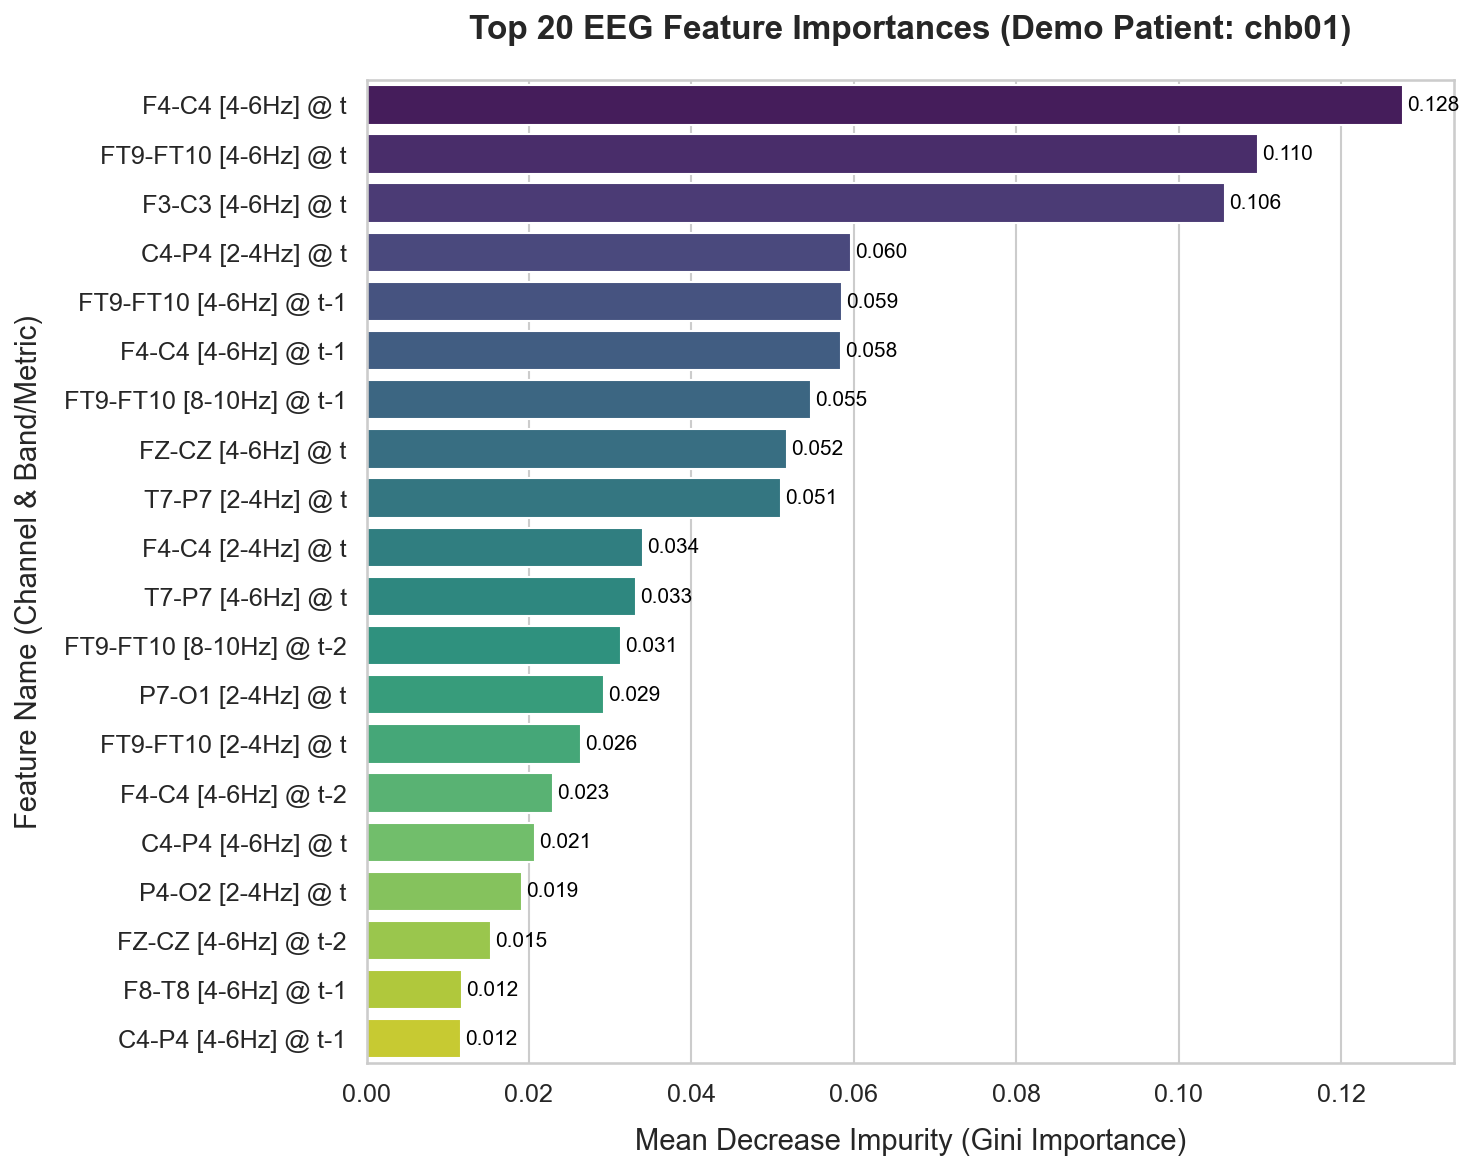

✅ 图表绘制完成！高清学术图片已保存至当前目录: feature_importance_top20_chb01.png


In [20]:
# =============================================================================
# Block 19. 特征重要性可视化 (Feature Importance Visualization)
# =============================================================================
# 确保特征重要性数据已存在
if "deploy_importance_df" not in globals() or "demo_patient_id" not in globals():
    raise ValueError("未找到 deploy_importance_df 或 demo_patient_id，请确保已运行 Block 17！")

print("---------------------------------------------------------")
print("Block 19: 绘制 Top-20 特征重要性条形图 (Bar Chart)")
print("---------------------------------------------------------")

# 提取前 20 个最重要的特征
top20_df = deploy_importance_df.head(20).copy()

# ----------------- 学术图表样式设置 -----------------
# 设置高分辨率和清爽的网格背景
plt.rcParams['figure.dpi'] = 150
sns.set_theme(style="whitegrid", font_scale=1.1)

# 创建画布 (宽 10, 高 8，适合展示 20 个水平条目)
plt.figure(figsize=(10, 8))

# 绘制水平条形图 (Horizontal Barplot)
# palette="viridis" 提供了一个科学界常用的、对色弱友好的渐变色系
ax = sns.barplot(
    x="Importance", 
    y="Feature_Name", 
    data=top20_df, 
    palette="viridis",
    hue="Feature_Name", # 避免 seaborn 未来版本的警告
    legend=False
)

# 添加标题和坐标轴标签
plt.title(f"Top 20 EEG Feature Importances (Demo Patient: {demo_patient_id})", 
          pad=20, fontsize=16, fontweight='bold')
plt.xlabel("Mean Decrease Impurity (Gini Importance)", fontsize=14, labelpad=10)
plt.ylabel("Feature Name (Channel & Band/Metric)", fontsize=14, labelpad=10)

# ----------------- 添加数据标签 -----------------
# 遍历每个条形，在末尾添加具体的数值，方便精确读取
for p in ax.patches:
    width = p.get_width()
    # 过滤掉宽度为 0 的情况（防止报错）
    if width > 0:
        plt.text(
            width + 0.0005,  # 向右偏移一点点
            p.get_y() + p.get_height() / 2., 
            f'{width:.3f}', 
            ha="left", 
            va="center", 
            fontsize=10,
            color='black'
        )

# 自动调整边界，防止特征名字太长被边缘截断
plt.tight_layout()

# 导出为 300 DPI 的高清 PNG 图片
output_filename = f"feature_importance_top20_{demo_patient_id}.png"
plt.savefig(output_filename, dpi=300, bbox_inches='tight')

# 在 Jupyter Notebook 中展示图表
plt.show()

print(f"✅ 图表绘制完成！高清学术图片已保存至当前目录: {output_filename}")

## Block 20. Inference Latency And Resource Profiling

这里不再像原 notebook 一样硬编码对比数值，而是直接对**当前训练出来的部署模型**做测量。

包含两部分：

- **单步推理延迟**：模拟真实设备一次只送入一个 epoch
- **资源画像**：统计模型字节数、树数、决策节点数



In [21]:
# =============================================================================
# Block 20. Inference Latency and Resource Profiling (Demo Patient Model) - Academic Table Output
# =============================================================================
def benchmark_single_epoch_latency(model, X_stream: np.ndarray, n_steps: int = 1000) -> Dict[str, float]:
    n_steps = min(n_steps, len(X_stream))
    timings = []
    for i in range(n_steps):
        sample = X_stream[i : i + 1]
        t0 = time.perf_counter()
        _ = model.predict_proba(sample)
        t1 = time.perf_counter()
        timings.append(t1 - t0)
    timings = np.asarray(timings)
    return {
        "n_steps": int(n_steps),
        "mean_ms": float(np.mean(timings) * 1000.0),
        "median_ms": float(np.median(timings) * 1000.0),
        "p95_ms": float(np.percentile(timings, 95) * 1000.0),
        "fps_estimate": float(1.0 / np.mean(timings)) if np.mean(timings) > 0 else np.nan,
    }

def profile_rf_model(model, input_dim: int) -> Dict[str, float]:
    buffer = io.BytesIO()
    joblib.dump(model, buffer)
    raw_bytes = buffer.getvalue()
    estimators = list(getattr(model, "estimators_", []))
    total_nodes = int(sum(est.tree_.node_count for est in estimators)) if estimators else 0
    total_leaves = int(sum(np.sum(est.tree_.children_left == -1) for est in estimators)) if estimators else 0
    max_depth = int(max(est.tree_.max_depth for est in estimators)) if estimators else 0
    mean_depth = float(np.mean([est.tree_.max_depth for est in estimators])) if estimators else 0.0

    return {
        "input_dim": int(input_dim),
        "memory_mb": float(len(raw_bytes) / (1024.0 * 1024.0)), # Changed to MB for better readability
        "n_trees": int(len(estimators)),
        "total_nodes": int(total_nodes),
        "total_leaves": int(total_leaves),
        "decision_nodes": int(total_nodes - total_leaves),
        "max_tree_depth": int(max_depth),
        "mean_tree_depth": float(mean_depth),
    }

# --- Execution Logic ---
if "demo_patient_id" not in globals() or "patient_final_models" not in globals():
    raise ValueError("Please run Block 17 first to generate patient_final_models.")

demo_bundle = patient_final_models[demo_patient_id]
demo_payload = deploy_caches[demo_patient_id] # Ensure deploy_caches is available in global variables
X_demo_full, y_demo_full = collect_rows_from_files(demo_payload, list(demo_payload["files"].keys()), None)
X_demo_light = X_demo_full[:, demo_bundle["top_k_indices"]]

X_latency_stream = X_demo_light[: min(1500, len(X_demo_light))]
lat = benchmark_single_epoch_latency(demo_bundle["model"], X_latency_stream, n_steps=1000)
hw = profile_rf_model(demo_bundle["model"], input_dim=int(demo_bundle["input_dim"]))

# --- Build formatted Markdown tables ---
markdown_output = f"""
### Table 1: Real-time Inference Latency Evaluation for Wearable Devices (Demo Patient: {demo_patient_id})

| Metrics | Value | Description |
| :--- | :--- | :--- |
| **Test Epochs** | {lat['n_steps']} | Baseline for continuous inference stability test |
| **Mean Latency** | **{lat['mean_ms']:.2f} ms** | Average processing time per data epoch |
| **Median Latency** | {lat['median_ms']:.2f} ms | Central tendency of the data distribution |
| **P95 Latency** | **{lat['p95_ms']:.2f} ms** | Worst-case response guarantee of the system |
| **Throughput** | {lat['fps_estimate']:.1f} FPS | Number of EEG epochs processed per second |

### Table 2: Hardware and Memory Overhead Profiling of Random Forest Model

| Model Architecture | Value | Resource Overhead | Value |
| :--- | :--- | :--- | :--- |
| **Input Dim** | {hw['input_dim']} | **Memory Footprint**| **{hw['memory_mb']:.2f} MB** |
| **Number of Trees** | {hw['n_trees']} | **Total Nodes** | {hw['total_nodes']:,} |
| **Max Tree Depth** | {hw['max_tree_depth']} | **Decision Nodes** | {hw['decision_nodes']:,} |
| **Mean Tree Depth** | {hw['mean_tree_depth']:.1f} | **Leaf Nodes** | {hw['total_leaves']:,} |
"""

display(Markdown(markdown_output))
print("✅ Block 20 Complete: Resource profiling for demo patient model generated.")


### Table 1: Real-time Inference Latency Evaluation for Wearable Devices (Demo Patient: chb01)

| Metrics | Value | Description |
| :--- | :--- | :--- |
| **Test Epochs** | 1000 | Baseline for continuous inference stability test |
| **Mean Latency** | **80.99 ms** | Average processing time per data epoch |
| **Median Latency** | 70.89 ms | Central tendency of the data distribution |
| **P95 Latency** | **131.05 ms** | Worst-case response guarantee of the system |
| **Throughput** | 12.3 FPS | Number of EEG epochs processed per second |

### Table 2: Hardware and Memory Overhead Profiling of Random Forest Model

| Model Architecture | Value | Resource Overhead | Value |
| :--- | :--- | :--- | :--- |
| **Input Dim** | 30 | **Memory Footprint**| **2.99 MB** |
| **Number of Trees** | 500 | **Total Nodes** | 36,706 |
| **Max Tree Depth** | 12 | **Decision Nodes** | 18,103 |
| **Mean Tree Depth** | 12.0 | **Leaf Nodes** | 18,603 |


✅ Block 20 Complete: Resource profiling for demo patient model generated.


# Block 21. Extreme Model Compression: Exporting RF to C Header (Optimized)

In [22]:
# =============================================================================
# Block 21. Extreme Model Compression: Exporting RF to C Header (Optimized)
# =============================================================================
# Ensure emlearn is installed for embedded C generation
try:
    import emlearn
except ImportError:
    print("emlearn library not found. Installing it now...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "emlearn"])
    import emlearn

print("---------------------------------------------------------")
print("Block 21: Extreme Model Compression (RF -> Optimized C Header)")
print("---------------------------------------------------------")

if "deploy_model" not in globals():
    raise ValueError("deploy_model not found. Please ensure Block 17 has been run!")

# Identify the number of trees in the Random Forest
tree_count = len(getattr(deploy_model, "estimators_", []))
print(f"Converting the model with {tree_count} trees to an optimized C header file...")
print("Using emlearn to flatten the tree structure into 1D arrays for MCU deployment...\n")

try:
    # Convert the scikit-learn model to embedded C using the 'inline' method
    # This avoids deep recursion and uses efficient array lookups instead.
    cmodel = emlearn.convert(deploy_model, method='inline')
    
    # Save the generated C code to a local header file
    c_file_path = "eeg_seizure_detector_rf.h"
    cmodel.save(file=c_file_path, name="eeg_rf")

    # Measure the actual file size of the generated header
    file_size_kb = os.path.getsize(c_file_path) / 1024.0

    print(f"✅ Conversion successful! Optimized C header saved to: {c_file_path}")
    print(f"📄 File Size (Memory Footprint): {file_size_kb:.2f} KB")
    print("\n💡 Engineering Note:")
    print("This file contains flat arrays (nodes, leaves, thresholds) rather than nested if-else statements.")
    print("It eliminates stack overflow risks and is fully compatible with MCU Flash memory (PROGMEM).")
    
except Exception as e:
    print(f"❌ An error occurred during conversion: {e}")

---------------------------------------------------------
Block 21: Extreme Model Compression (RF -> Optimized C Header)
---------------------------------------------------------
Converting the model with 500 trees to an optimized C header file...
Using emlearn to flatten the tree structure into 1D arrays for MCU deployment...

✅ Conversion successful! Optimized C header saved to: eeg_seizure_detector_rf.h
📄 File Size (Memory Footprint): 3396.45 KB

💡 Engineering Note:
This file contains flat arrays (nodes, leaves, thresholds) rather than nested if-else statements.
It eliminates stack overflow risks and is fully compatible with MCU Flash memory (PROGMEM).


## Block 22. Patient-Level Final Model Summary


In [23]:
# =============================================================================
# Block 22. Patient-Level Final Model Summary - Academic Table Output
# =============================================================================
if "patient_final_models" not in globals() or len(patient_final_models) == 0:
    raise ValueError("Please run Block 17 first to generate patient_final_models.")

summary_rows = []
for pid, bundle in sorted(patient_final_models.items()):
    model = bundle["model"]
    tree_count = len(model.estimators_)
    node_count = sum(estimator.tree_.node_count for estimator in model.estimators_)
    
    summary_rows.append(
        {
            "Patient": pid,
            "InputDim": int(bundle["input_dim"]),
            "Threshold": float(bundle["threshold"]),
            "TrainRows": int(bundle["train_rows"]),
            "Pos Ratio": f"{(bundle['train_pos'] / bundle['train_rows'] * 100):.2f}%",
            "TreeCount": int(tree_count),
            "NodeCount": int(node_count),
        }
    )

df_summary = pd.DataFrame(summary_rows)

# Generate Markdown table string
md_table = "| Patient ID | Input Dim | Decision Threshold | Total Train Rows | Positive Ratio | RF Trees | Total Nodes |\n"
md_table += "| :---: | :---: | :---: | :---: | :---: | :---: | :---: |\n"

for _, row in df_summary.iterrows():
    md_table += f"| **{row['Patient']}** | {row['InputDim']} | {row['Threshold']:.3f} | {row['TrainRows']:,} | {row['Pos Ratio']} | {row['TreeCount']} | {row['NodeCount']:,} |\n"

# Summary statistics
md_summary = f"""
### Table 3: Summary of Patient-Specific Model Parameters

{md_table}

**Statistical Summary:**
* **Total Models**: {len(df_summary)}
* **Average Input Dimension**: {df_summary['InputDim'].mean():.1f}
* **Average Node Count**: {df_summary['NodeCount'].mean():,.0f} nodes/model
"""

display(Markdown(md_summary))
print("✅ Block 22 Complete: Patient-level model summary generated.")


### Table 3: Summary of Patient-Specific Model Parameters

| Patient ID | Input Dim | Decision Threshold | Total Train Rows | Positive Ratio | RF Trees | Total Nodes |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **chb01** | 30 | 0.499 | 72,993 | 0.31% | 500 | 36,706 |
| **chb02** | 30 | 0.308 | 63,479 | 0.14% | 500 | 18,664 |
| **chb03** | 30 | 0.672 | 68,403 | 0.30% | 500 | 30,636 |
| **chb04** | 30 | 0.742 | 280,914 | 0.07% | 500 | 51,378 |
| **chb05** | 30 | 0.482 | 70,205 | 0.40% | 500 | 39,088 |
| **chb06** | 30 | 0.308 | 120,122 | 0.07% | 500 | 56,998 |
| **chb07** | 30 | 0.690 | 120,693 | 0.14% | 500 | 40,504 |
| **chb08** | 30 | 0.464 | 36,011 | 1.28% | 500 | 139,280 |
| **chb09** | 30 | 0.690 | 122,165 | 0.12% | 500 | 24,408 |
| **chb10** | 30 | 0.811 | 90,041 | 0.25% | 500 | 29,960 |


**Statistical Summary:**
* **Total Models**: 10
* **Average Input Dimension**: 30.0
* **Average Node Count**: 46,762 nodes/model


✅ Block 22 Complete: Patient-level model summary generated.


## Block 23. Export Final Patient Models And Metadata



In [24]:
# =============================================================================
# Block 23. 导出 10 位病人的最终模型与 metadata
# 作用：
# 1) 每病人导出一个 RF joblib 模型；
# 2) 每病人导出 metadata；
# 3) 生成总索引 CSV/JSON，便于部署系统读取。
# =============================================================================
if "patient_final_models" not in globals() or len(patient_final_models) == 0:
    raise ValueError("请先运行 Block 17（v9 add-on），生成 patient_final_models。")

base_export_paths = get_export_paths(deploy_cfg)
export_root = base_export_paths["model"].parent
patient_export_root = export_root / "patient_models"
ensure_dir(patient_export_root)

export_rows = []
for pid, bundle in sorted(patient_final_models.items()):
    patient_dir = patient_export_root / pid
    ensure_dir(patient_dir)

    model_path = patient_dir / "rf_model.joblib"
    metadata_path = patient_dir / "metadata.json"

    joblib.dump(bundle["model"], model_path)

    meta = {
        "version": "refactored-notebook-optimized-rf",
        "patient_id": pid,
        "config_hash": config_to_hash(deploy_cfg),
        "model_name": "random_forest_patient_specific",
        "input_dim": int(bundle["input_dim"]),
        "threshold": float(bundle["threshold"]),
        "requested_top_k": int(final_top_k),
        "top_k_indices": [int(x) for x in bundle["top_k_indices"].tolist()],
        "top_k_feature_names": bundle["feature_names"],
        "feature_history_epochs": int(deploy_cfg.feature.history_epochs),
        "epoch_len_s": int(deploy_cfg.feature.epoch_len_s),
        "bandpass_method": deploy_cfg.feature.bandpass_method,
        "butter_order": int(deploy_cfg.feature.butter_order),
        "channel_missing_policy": deploy_cfg.feature.channel_missing_policy,
        "rf_n_estimators": int(deploy_cfg.eval.rf_n_estimators),
        "rf_max_depth": None if deploy_cfg.eval.rf_max_depth is None else int(deploy_cfg.eval.rf_max_depth),
        "rf_min_samples_leaf": int(deploy_cfg.eval.rf_min_samples_leaf),
        "rf_max_features": str(deploy_cfg.eval.rf_max_features),
    }
    save_json(meta, metadata_path)

    bundle["export_model_path"] = str(model_path)
    bundle["export_metadata_path"] = str(metadata_path)

    export_rows.append(
        {
            "Patient": pid,
            "ModelPath": str(model_path),
            "MetadataPath": str(metadata_path),
            "Threshold": float(bundle["threshold"]),
            "InputDim": int(bundle["input_dim"]),
            "TopK": int(len(bundle["top_k_indices"])),
        }
    )

patient_export_index_df = pd.DataFrame(export_rows).sort_values("Patient").reset_index(drop=True)
display(patient_export_index_df)

patient_index_csv = patient_export_root / "patient_model_index.csv"
patient_index_json = patient_export_root / "patient_model_index.json"

patient_export_index_df.to_csv(patient_index_csv, index=False, encoding="utf-8-sig")
save_json(patient_export_index_df.to_dict(orient="records"), patient_index_json)

# 兼容后续脚本生成块
export_paths = {
    "patient_root": patient_export_root,
    "index_csv": patient_index_csv,
    "index_json": patient_index_json,
    "service_script": export_root / "serve_patient_models.py",
    "client_script": export_root / "example_client_patient.py",
}

print("patient model root:", patient_export_root)
print("patient index csv:", patient_index_csv)
print("patient index json:", patient_index_json)
print("✅ Block 23 完成：10位病人模型导出成功。")


,Patient,ModelPath,MetadataPath,Threshold,InputDim,TopK
0,chb01,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\e...,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\e...,0.499,30,30
1,chb02,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\e...,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\e...,0.308,30,30
2,chb03,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\e...,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\e...,0.672,30,30
3,chb04,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\e...,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\e...,0.742,30,30
4,chb05,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\e...,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\e...,0.482,30,30
5,chb06,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\e...,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\e...,0.308,30,30
6,chb07,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\e...,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\e...,0.690,30,30
7,chb08,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\e...,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\e...,0.464,30,30
8,chb09,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\e...,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\e...,0.690,30,30
9,chb10,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\e...,D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\e...,0.811,30,30


patient model root: D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\exported_models\patient_models
patient index csv: D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\exported_models\patient_models\patient_model_index.csv
patient index json: D:\EEG_Data\chb-mit-scalp-eeg-database-1.0.0\exported_models\patient_models\patient_model_index.json
✅ Block 23 完成：10位病人模型导出成功。


## Block 26. Clinical Visualization



,Patient,File,Threshold,Hit_In_Seizure,False_Alarm_Before_Onset,First_Alarm_Relative_s,Missing_Channels
0,chb01,chb01_03.edf,0.499,True,False,0.0,0


,epoch_index,time_s,time_rel_s,y_true,prob,alarm
0,1490,2980,-16,0,0.000000,False
1,1491,2982,-14,0,0.000000,False
2,1492,2984,-12,0,0.000000,False
3,1493,2986,-10,0,0.000000,False
4,1494,2988,-8,0,0.000000,False
5,1495,2990,-6,0,0.000000,False
6,1496,2992,-4,0,0.000000,False
7,1497,2994,-2,0,0.000000,False
8,1498,2996,0,1,0.597041,True
9,1499,2998,2,1,0.618864,True


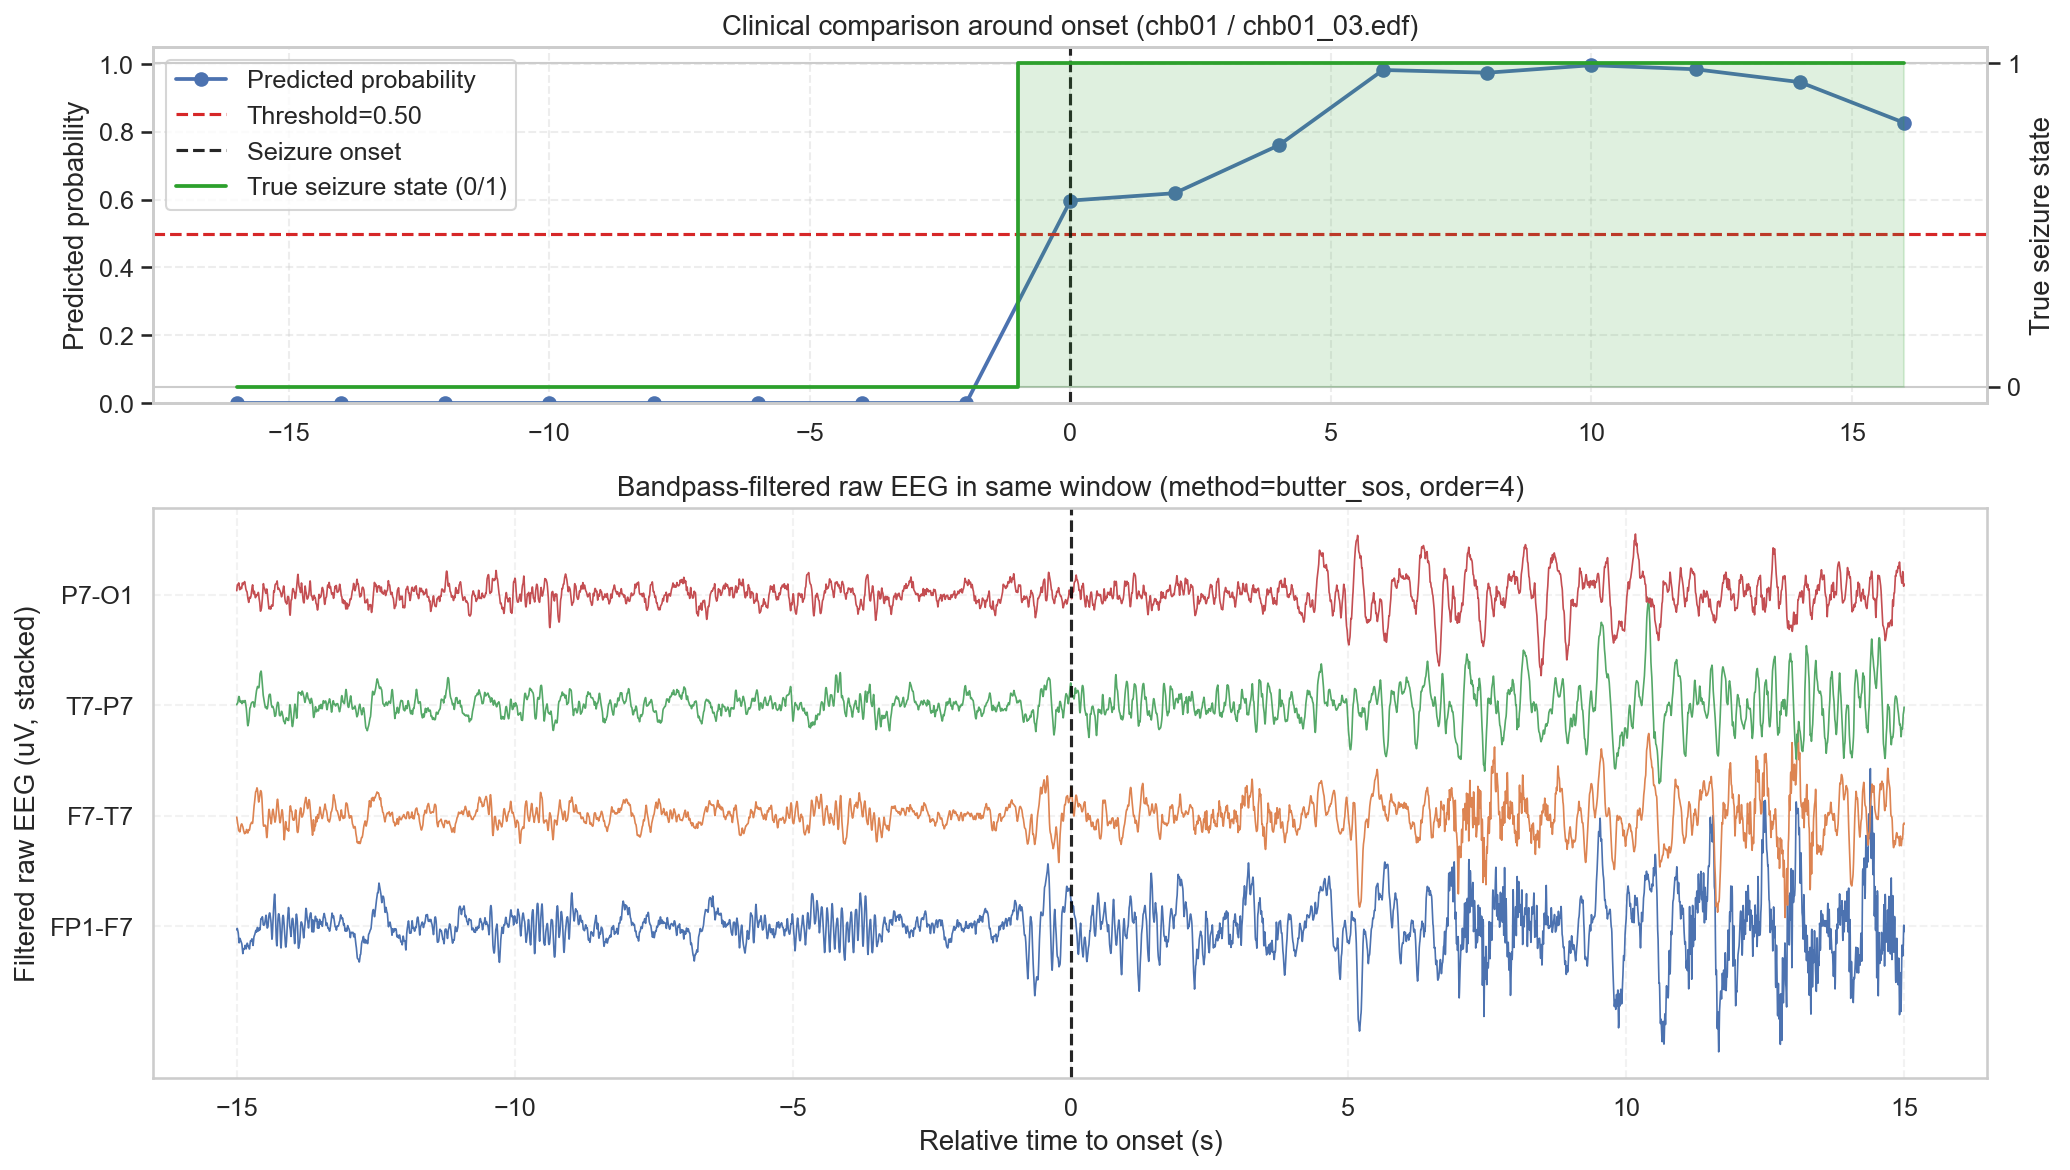

Clinical check | Hit in seizure: True | False alarm before onset: False | First alarm relative time (s): 0.0
Block 26 done: probability-vs-true-state and filtered raw EEG are both shown.


In [27]:
# =============================================================================
# Block 26. Clinical single-case view: probability + true state + filtered EEG
# =============================================================================
def align_channels_window(
    raw: mne.io.BaseRaw,
    target_channels: Sequence[str],
    start_idx: int,
    stop_idx: int,
    policy: str = "strict",
) -> Tuple[np.ndarray, Dict[str, Any]]:
    """Window-based channel alignment with pre-allocated output (optimization #19).
    NOTE: Logic mirrors align_channels(); consider merging in future refactor.
    """
    normalized_targets = [normalize_channel_name(ch) for ch in target_channels]
    existing = {normalize_channel_name(ch): ch for ch in raw.ch_names}

    n_ch = len(normalized_targets)
    n_times = stop_idx - start_idx
    data = np.zeros((n_ch, n_times), dtype=float)
    missing_channels = []
    reversed_channels = []

    for i, target in enumerate(normalized_targets):
        if target in existing:
            data[i] = raw.get_data(picks=[existing[target]], start=start_idx, stop=stop_idx)[0]
            continue

        if "-" in target:
            reverse_target = "-".join(target.split("-")[::-1])
            if reverse_target in existing:
                data[i] = -raw.get_data(picks=[existing[reverse_target]], start=start_idx, stop=stop_idx)[0]
                reversed_channels.append(target)
                continue

        if policy == "zero_fill":
            # data[i] already zeros
            missing_channels.append(target)
        else:
            raise ValueError(f"Missing target channel: {target}")

    info = {
        "missing_channels": missing_channels,
        "missing_count": len(missing_channels),
        "reversed_channels": reversed_channels,
    }
    return data, info


def build_clinical_case_dataframe(
    patient_id: str,
    patient_payload: Dict[str, Any],
    model,
    feature_indices: np.ndarray,
    threshold: float,
    pre_seconds: int = 12,
    post_seconds: int = 14,
) -> Tuple[str, pd.DataFrame, Dict[str, Any]]:
    seizure_files = [
        f for f, d in patient_payload["files"].items()
        if d["has_seizure"] and d.get("has_positive_epoch", False)
    ]
    if not seizure_files:
        seizure_files = [f for f, d in patient_payload["files"].items() if d["has_seizure"]]
    if not seizure_files:
        raise ValueError(f"No seizure file found for {patient_id}.")

    file_name = sorted(seizure_files)[0]
    item = patient_payload["files"][file_name]

    X = item["X"][:, feature_indices]
    y = item["y"].astype(np.int8)

    seizure_positions = np.flatnonzero(y == 1)
    if len(seizure_positions) == 0:
        raise ValueError(f"No positive epochs in {patient_id}/{file_name}.")

    onset_epoch = int(seizure_positions[0])
    _cfg_case = deploy_cfg if "deploy_cfg" in globals() else CFG
    epoch_len_s = _cfg_case.feature.epoch_len_s
    onset_time_s = onset_epoch * epoch_len_s

    pre_epochs = max(1, int(np.ceil(pre_seconds / epoch_len_s)))
    post_epochs = max(1, int(np.ceil(post_seconds / epoch_len_s)))

    start_epoch = max(0, onset_epoch - pre_epochs)
    end_epoch = min(len(y), onset_epoch + post_epochs + 1)

    epoch_indices = np.arange(start_epoch, end_epoch)
    probs = model.predict_proba(X[start_epoch:end_epoch])[:, 1]
    alarms = probs >= threshold

    case_df = pd.DataFrame(
        {
            "epoch_index": epoch_indices,
            "time_s": epoch_indices * epoch_len_s,
            "time_rel_s": (epoch_indices - onset_epoch) * epoch_len_s,
            "y_true": y[start_epoch:end_epoch],
            "prob": probs,
            "alarm": alarms.astype(bool),
        }
    )

    hit_in_seizure = bool(np.any((case_df["y_true"] == 1) & (case_df["alarm"])))
    false_alarm_before = bool(np.any((case_df["time_rel_s"] < 0) & (case_df["alarm"])))
    first_alarm_rel_s = float(case_df.loc[case_df["alarm"], "time_rel_s"].iloc[0]) if np.any(case_df["alarm"]) else np.nan

    metrics = {
        "patient_id": patient_id,
        "file_name": file_name,
        "onset_epoch": onset_epoch,
        "onset_time_s": onset_time_s,
        "threshold": float(threshold),
        "hit_in_seizure": hit_in_seizure,
        "false_alarm_before": false_alarm_before,
        "first_alarm_rel_s": first_alarm_rel_s,
    }
    return file_name, case_df, metrics


def load_filtered_eeg_segment(
    cfg: ExperimentConfig,
    patient_id: str,
    file_name: str,
    start_time_s: float,
    end_time_s: float,
    onset_time_s: float,
    plot_channels: Sequence[str],
) -> Tuple[np.ndarray, np.ndarray, List[str], Dict[str, Any]]:
    edf_path = Path(cfg.data_root) / patient_id / file_name
    if not edf_path.exists():
        raise FileNotFoundError(f"EDF not found: {edf_path}")

    raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
    raw = deduplicate_and_normalize_raw(raw)
    fs = int(raw.info["sfreq"])

    start_idx = max(0, int(start_time_s * fs))
    stop_idx = min(raw.n_times, int(end_time_s * fs))
    if stop_idx <= start_idx:
        raw.close()
        raise ValueError("Invalid EEG window: stop <= start")

    data_window, align_info = align_channels_window(
        raw=raw,
        target_channels=cfg.channels,
        start_idx=start_idx,
        stop_idx=stop_idx,
        policy=cfg.feature.channel_missing_policy,
    )
    raw.close()

    if cfg.feature.scale_to_uV:
        data_window = data_window * 1e6

    data_bp = bandpass_filter_multich(
        data_window,
        fs=fs,
        lowcut=cfg.feature.bandpass_low_hz,
        highcut=cfg.feature.bandpass_high_hz,
        method=cfg.feature.bandpass_method,
        butter_order=cfg.feature.butter_order,
    )

    target_norm = [normalize_channel_name(ch) for ch in cfg.channels]
    plot_indices = []
    plot_names = []
    for ch in plot_channels:
        ch_norm = normalize_channel_name(ch)
        if ch_norm in target_norm:
            plot_indices.append(target_norm.index(ch_norm))
            plot_names.append(ch)

    if len(plot_indices) == 0:
        plot_indices = list(range(min(4, data_bp.shape[0])))
        plot_names = [cfg.channels[idx] for idx in plot_indices]

    eeg_plot = data_bp[plot_indices]
    t_abs = np.arange(eeg_plot.shape[1]) / fs + (start_idx / fs)
    t_rel = t_abs - onset_time_s

    return eeg_plot, t_rel, plot_names, align_info


clinical_patient_id = demo_patient_id if "demo_patient_id" in globals() else next(iter(caches.keys()))
clinical_file, clinical_df, clinical_metrics = build_clinical_case_dataframe(
    patient_id=clinical_patient_id,
    patient_payload=(deploy_caches if "deploy_caches" in globals() else caches)[clinical_patient_id],
    model=deploy_model,
    feature_indices=deploy_topk_indices,
    threshold=deploy_threshold,
    pre_seconds=15,
    post_seconds=15,
)

window_start_s = float(clinical_metrics["onset_time_s"] - 15)
window_end_s = float(clinical_metrics["onset_time_s"] + 15)

eeg_plot, eeg_t_rel, eeg_names, eeg_align_info = load_filtered_eeg_segment(
    cfg=deploy_cfg if "deploy_cfg" in globals() else CFG,
    patient_id=clinical_patient_id,
    file_name=clinical_file,
    start_time_s=max(0.0, window_start_s),
    end_time_s=window_end_s,
    onset_time_s=float(clinical_metrics["onset_time_s"]),
    plot_channels=["FP1-F7", "F7-T7", "T7-P7", "P7-O1"],
)

status_row = pd.DataFrame(
    [
        {
            "Patient": clinical_patient_id,
            "File": clinical_file,
            "Threshold": clinical_metrics["threshold"],
            "Hit_In_Seizure": clinical_metrics["hit_in_seizure"],
            "False_Alarm_Before_Onset": clinical_metrics["false_alarm_before"],
            "First_Alarm_Relative_s": clinical_metrics["first_alarm_rel_s"],
            "Missing_Channels": eeg_align_info["missing_count"],
        }
    ]
)
display(status_row)
display(clinical_df)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [1.0, 1.6]})

# Panel 1: probability + threshold + true seizure state in the same panel
ax_prob = axes[0]
ax_true = ax_prob.twinx()

ax_prob.plot(clinical_df["time_rel_s"], clinical_df["prob"], marker="o", lw=1.8, label="Predicted probability")
ax_prob.axhline(clinical_metrics["threshold"], color="tab:red", linestyle="--", label=f"Threshold={clinical_metrics['threshold']:.2f}")
ax_prob.axvline(0, color="black", linestyle="--", alpha=0.85, label="Seizure onset")

ax_true.step(
    clinical_df["time_rel_s"],
    clinical_df["y_true"],
    where="mid",
    color="tab:green",
    lw=1.8,
    label="True seizure state (0/1)",
)
ax_true.fill_between(
    clinical_df["time_rel_s"],
    0,
    clinical_df["y_true"],
    step="mid",
    color="tab:green",
    alpha=0.15,
)

ax_prob.set_ylabel("Predicted probability")
ax_prob.set_ylim(0, 1.05)
ax_true.set_ylabel("True seizure state")
ax_true.set_ylim(-0.05, 1.05)
ax_true.set_yticks([0, 1])
ax_prob.set_title(f"Clinical comparison around onset ({clinical_patient_id} / {clinical_file})")
ax_prob.grid(True, linestyle="--", alpha=0.35)

h1, l1 = ax_prob.get_legend_handles_labels()
h2, l2 = ax_true.get_legend_handles_labels()
ax_prob.legend(h1 + h2, l1 + l2, loc="best")

# Panel 2: filtered raw EEG for clinical review
signal_scale = float(np.nanpercentile(np.abs(eeg_plot), 95))
offset = max(signal_scale * 2.5, 5.0)
for i, (name, sig) in enumerate(zip(eeg_names, eeg_plot)):
    axes[1].plot(eeg_t_rel, sig + i * offset, lw=0.8)

axes[1].set_yticks([i * offset for i in range(len(eeg_names))])
axes[1].set_yticklabels(eeg_names)
axes[1].axvline(0, color="black", linestyle="--", alpha=0.85)
axes[1].set_xlabel("Relative time to onset (s)")
axes[1].set_ylabel("Filtered raw EEG (uV, stacked)")
_cfg_vis = deploy_cfg if "deploy_cfg" in globals() else CFG
axes[1].set_title(
    f"Bandpass-filtered raw EEG in same window (method={_cfg_vis.feature.bandpass_method}, order={_cfg_vis.feature.butter_order})"
)
axes[1].grid(True, linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

print(
    f"Clinical check | Hit in seizure: {clinical_metrics['hit_in_seizure']} | "
    f"False alarm before onset: {clinical_metrics['false_alarm_before']} | "
    f"First alarm relative time (s): {clinical_metrics['first_alarm_rel_s']}"
)
print("Block 26 done: probability-vs-true-state and filtered raw EEG are both shown.")




## 每个代码块的解释（含 1D CNN 新增部分）

1. **Block 1**：导入整个项目需要的依赖，并固定随机种子，保证实验结果尽量可复现。
2. **Block 2**：定义全局配置类，把数据路径、特征参数、评估参数和导出参数统一管理起来。
3. **Block 3**：提供缓存命名、JSON 读写、目录创建等通用工具函数，方便后续复用。
4. **Block 4**：处理原始 EEG 文件、summary 标注和通道名称对齐，为特征提取做准备。
5. **Block 5**：完成带通滤波、频带能量特征提取、同步性特征提取，以及时序堆叠特征构造。
6. **Block 6**：定义事件级 sensitivity、FAR/hour、delay 等指标，同时给出负样本抽样和验证集阈值选择逻辑。
7. **Block 7**：把每位病人的 EDF 数据转成 epoch 级缓存，避免后面每次实验都重新提特征。
8. **Block 8**：加载缓存并做一致性检查，确保所有病人的缓存都来自同一组配置。
9. **Block 9**：定义传统模型工厂和 LOSO 评估入口，统一 SVM、RF、XGBoost 的训练与测试流程。
10. **Block 10**：实际构建或复用缓存，并统计 chb01-chb10 的覆盖情况。
11. **Block 11**：作为流程检查点，提醒当前 notebook 包含参数搜索、模型比较和部署相关链路。
12. **Block 12A**：小范围搜索 history、滤波方式和滤波阶数，找出更合适的特征配置。
13. **Block 12B**：在 Block 12A 最优特征基础上继续搜索 RF 的 top-k 和超参数，得到最终 RF 部署配置。
14. **Block 13**：整理最终评估阶段会复用的汇总函数，并统一解析最终 RF 的上下文配置。
15. **Block 13B**：新增 1D CNN 所需的工具函数，包括张量 reshape、标准化、模型结构、训练循环和 LOSO 评估接口。
16. **Block 14**：保留原始传统模型 benchmark，先比较 SVM、Random Forest 和 XGBoost。
17. **Block 14A**：只新增 1D CNN 的计算，不改前面的参数扫描；运行后会把 `cnn_1d` 自动并入原来的模型比较表。
18. **Block 14B**：把传统模型与可选的 1D CNN 统一画成可视化图表，输出宏观指标柱状图和病人级 heatmap。
19. **Block 15**：比较 RF 全特征和最终 top-k 特征的事件级表现，观察压缩前后性能变化。
20. **Block 16**：执行最终 RF 的 10 位病人 LOSO 验证，并得到后续病人专属模型训练所需的阈值映射。
21. **Block 17**：为每位病人训练一个最终 RF 模型，保存 top-k 特征索引、阈值和训练统计。
22. **Block 18**：不重新训练模型，只把前面生成的关键结果重新排版，方便论文和报告阅读。
23. **Block 19**：可视化最终 RF 模型的重要特征，帮助理解模型主要依赖哪些 EEG 特征。
24. **Block 20**：评估部署模型的推理延迟、吞吐率和模型大小，用于嵌入式或实时场景分析。
25. **Block 21**：把最终 RF 转换成 C 头文件，方便进一步部署到端侧或 MCU 环境。
26. **Block 22**：从病人维度汇总最终模型的输入维度、阈值、训练样本量和树结构复杂度。
27. **Block 23**：导出每位病人的最终模型和 metadata，并生成统一索引文件。
28. **Block 26**：给出临床单病例视图，把概率、真实标签和滤波后的 EEG 波形放在一起观察。

### 这次新增 1D CNN 的设计说明

- **为什么不改前面的参数扫描**：你的原始 notebook 已经把特征工程和 RF 调参流程跑通了，所以这次只额外增加一个深度学习模型，避免把之前的工作全部推倒重来。
- **为什么选 1D CNN**：当前特征已经做过时间堆叠，因此最自然的做法是把它恢复为多个连续时间步，再用 1D 卷积去学习相邻时间片之间的局部变化。
- **为什么还能公平比较**：1D CNN 继续沿用原 notebook 的缓存、负采样、验证集选阈值、平滑和最短报警持续时间约束，因此和传统模型的比较口径保持一致。
- **如何使用新增部分**：先运行到 Block 14 得到传统模型结果，再运行 Block 14A，把 `cnn_1d` 加入比较；最后运行 Block 14B 和 Block 18，就可以看到更新后的对比结果。
